# COMP 579 Assignment 3 - Question 1

Prepared by: Nicolas Smits

Presented to: Prof. Isabeau Premont Schwartz, Valliappan Chidambaram Adaikkappan

<b><u>NOTE</b></u>: I completed this on google colab which uses a different version of gym for Acrobot and Assault ram, so the lines with "state, _ = env.reset()" should be changed to "state = env.reset()" for the Acrobot env. Also, file paths should be updated acordingly.

In [1]:
!pip install ale-py gym[atari]

!pip install gym[accept-rom-license]
!ale-import-roms

usage: ale-import-roms [-h] [--version] [--dry-run] (--import-from-pkg IMPORT_FROM_PKG | romdir)
ale-import-roms: error: one of the arguments --import-from-pkg romdir is required


## Task 1 - Value Based Methods with Deep Neural Networks

In [3]:
import gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import os
import random
from tqdm import tqdm
import glob
import re
from collections import defaultdict

if not hasattr(np, 'float_'):
    np.float_ = np.float64

if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

import torch.serialization
torch.serialization.add_safe_globals(['numpy._core.multiarray._reconstruct'])

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Q-network Function Approximator
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size, hidden_size=None):
        super(QNetwork, self).__init__()
        if hidden_size is None:
            hidden_size = [256, 256]
        layers = []
        last_dim = state_size # input layer init
        # populate hidden layers
        for hidden_dim in hidden_size:
            layers.append(nn.Linear(last_dim, hidden_dim))
            layers.append(nn.ReLU())
            last_dim = hidden_dim
        # output layer
        layers.append(nn.Linear(last_dim, action_size))
        self.model = nn.Sequential(*layers)
        self.apply(init_weights) # initialize weights (method in cell below)

    def forward(self, x):
        return self.model(x)

# Replay Buffer
class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = []
        self.position = 0

    # store experience in replay buffer
    def push(self, state, action, reward, next_state, done):
      state = np.asarray(state)
      next_state = np.asarray(next_state)
      if len(self.buffer) < self.capacity:  # buffer not full
          self.buffer.append(None)
      self.buffer[self.position] = (state, action, reward, next_state, done)
      self.position = (self.position + 1) % self.capacity  # update position

    # sample from buffer
    def sample(self, batch_size):
      batch = random.sample(self.buffer, batch_size)
      states, actions, rewards, next_states, dones = zip(*batch)
      return (np.stack(states),
              np.array(actions),
              np.array(rewards, dtype=np.float32),
              np.stack(next_states),
              np.array(dones, dtype=np.uint8))

    def __len__(self):
        return len(self.buffer)

# Agent Superclass
class Agent:
    def __init__(self, env, alpha=1e-3, gamma=0.99, epsilon=0.1):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

        # assume the obseration space is a vector
        state_space = env.observation_space.shape[0] # state space dimension
        action_space = env.action_space.n # action space dimension

        # for GPU acceleration
        if torch.backends.mps.is_available():
            self.device = torch.device("mps") # m1 macos gang wya
        elif torch.cuda.is_available():
            self.device = torch.device("cuda")
        else:
            self.device = torch.device("cpu")

        print(f"Using device: {self.device}")

        # Q-network
        self.q_network = QNetwork(state_space, action_space).to(self.device) # initialize Q-network
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=alpha) # optimizer
        self.loss_fn = nn.MSELoss() # loss function
        # self.loss_fn = nn.SmoothL1Loss() # alternative

    # epsilon-greedy policy
    def select_action(self, state, greedy=False):
        if greedy:
            return self.q_network(torch.tensor(state, dtype=torch.float32).to(self.device)).argmax().item()
        else:
            if np.random.rand() < self.epsilon:
                return self.env.action_space.sample() # random action
            else:
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device) # convert state to tensor
                with torch.no_grad(): # no gradient calculation
                        q_values = self.q_network(state_tensor) # greedy action
                return int(torch.argmax(q_values, dim=1).item())

    # update Q-network (general method, plug in target computation from agent)
    def update(self, s, a, r, s_, done):
        """
        Update Q-network.

        Args:
            s: current state
            a: current action
            r: reward
            s_: next state
            done: whether the episode is done
        Returns:
            loss: loss value
        """
        self.optimizer.zero_grad()

        state_tensor = torch.FloatTensor(s).unsqueeze(0).to(self.device)
        next_state_tensor = torch.FloatTensor(s_).unsqueeze(0).to(self.device)

        q_values = self.q_network(state_tensor)
        predicted = q_values[0, a]

        # The algorithm-specific target computation is done in compute_target.
        target = self.compute_target(r, next_state_tensor, done) ## ALGORITHM-DEPENDENT (subclasses)
        loss = self.loss_fn(predicted, target)
        loss.backward()
        self.optimizer.step()
        return loss.item()

    # update Q-network for a batch of transitions
    def update_batch(self, batch):
        """
        Update Q-network for a batch of transitions.

        Args:
            batch: tuple of (states, actions, rewards, next_states, dones)

        Returns:
            loss: loss value
        """
        states, actions, rewards, next_states, dones = batch

        states_tensor = torch.FloatTensor(states).to(self.device)
        actions_tensor = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards_tensor = torch.FloatTensor(rewards).to(self.device)
        next_states_tensor = torch.FloatTensor(next_states).to(self.device)
        dones_tensor = torch.FloatTensor(dones).to(self.device)

        q_values = self.q_network(states_tensor)
        # gather Q-values corresponding to taken actions.
        predicted = q_values.gather(1, actions_tensor).squeeze(1)

        target = self.compute_target_batch(rewards_tensor, next_states_tensor, dones_tensor) ## ALGORITHM-DEPENDENT (subclasses)
        loss = self.loss_fn(predicted, target)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return loss.item()

    # methods are overridden by the subclass.
    def compute_target(self, reward, next_state_tensor, done):
        raise NotImplementedError("Override in subclass")

    def compute_target_batch(self, rewards_tensor, next_states_tensor, dones_tensor):
        raise NotImplementedError("Override in subclass")


class QLearningAgent(Agent):
    def __init__(self, env, alpha=1e-3, gamma=0.99, epsilon=0.1):
        super(QLearningAgent, self).__init__(env, alpha, gamma, epsilon)

    # update Q-network via Q-learning
    # @overrides(Agent)
    def compute_target(self, reward, next_state_tensor, done):
        if done:
            return torch.tensor(reward, dtype=torch.float32, device=self.device)
        else:
            with torch.no_grad():
                next_q_values = self.q_network(next_state_tensor)
            # Q-learning uses the maximum over next-state Q-values.
            max_next_q = torch.max(next_q_values)
            target = torch.tensor(reward, dtype=torch.float32, device=self.device) + self.gamma * max_next_q # Q target
            return target

    # @overrides(Agent)
    def compute_target_batch(self, rewards_tensor, next_states_tensor, dones_tensor):
        with torch.no_grad():
            next_q_values = self.q_network(next_states_tensor)
            max_next_q_values, _ = next_q_values.max(dim=1)
        target = rewards_tensor + self.gamma * max_next_q_values * (1 - dones_tensor)
        return target

class ExpectedSarsaAgent(Agent):
    def __init__(self, env, alpha=0.001, gamma=0.99, epsilon=0.1):
        super().__init__(env, alpha, gamma, epsilon)

    # @overrides(Agent)
    def compute_target(self, reward, next_state_tensor, done):
        if done:
            return torch.tensor(reward, dtype=torch.float32, device=self.device)
        else:
            with torch.no_grad():
                # compute Q-values for the next state from the Q-network
                next_q_values = self.q_network(next_state_tensor)

            num_actions = next_q_values.size(1) # num actions

            # compute epsilon-greedy probabilities.
            best_action = torch.argmax(next_q_values, dim=1).item() # best action
            probs = torch.ones(num_actions, device=self.device) * (self.epsilon / num_actions) # epsilon-greedy probs
            probs[best_action] += (1.0 - self.epsilon) # update best action prob
            expected_q = torch.sum(next_q_values[0] * probs)
            target = torch.tensor(reward, dtype=torch.float32, device=self.device) + self.gamma * expected_q

            return target

    # @override(Agent)
    def compute_target_batch(self, rewards_tensor, next_states_tensor, dones_tensor):
        with torch.no_grad():
            # compute Q-values for the next state from the Q-network
            next_q_values = self.q_network(next_states_tensor)
            num_actions = next_q_values.size(1) # num actions
            best_actions = next_q_values.argmax(dim=1) # best actions

            # build a probability tensor for the epsilon-greedy policy.
            probs = torch.ones_like(next_q_values) * (self.epsilon / num_actions)
            probs[range(probs.shape[0]), best_actions] += (1.0 - self.epsilon)
            expected_q = (next_q_values * probs).sum(dim=1)
        target = rewards_tensor + self.gamma * expected_q * (1 - dones_tensor)

        return target

# Training
def train_agent(agent, env, num_episodes=1000):
    """
    Train the agent in the given environment.

    Args:
        agent: Agent object
        env: OpenAI Gym environment
        num_episodes: number of episodes to train the agent
    Returns:
        None
    """
    agent.total_rewards = [] # store total rewards for each episode

    progress_bar = tqdm(range(num_episodes), total=num_episodes, desc="Episodes")
    for episode in progress_bar:
        state = env.reset()
        done = False
        total_reward = 0
        while not done:
            actions = env.action_space.n # get number of actions
            action = agent.select_action(state) # select action
            next_state, reward, terminated, truncated, info = env.step(action) # take action and observe next state and reward
            done = terminated or truncated
            total_reward += reward # update total reward
            loss = agent.update(state, action, reward, next_state, done) # update Q-network
            state = next_state
        agent.total_rewards.append(total_reward)
        progress_bar.set_description(f"Ep {episode+1}: Reward = {total_reward}")
    return agent.total_rewards

# with checkpointing
def train_agent_with_checkpoint(agent, env, num_episodes=1000,
                                checkpoint_path="checkpoint.pt", checkpoint_interval=500):
    """
    Train the agent in the given environment with checkpointing using a tqdm progress bar.
    Saves:
      - Agent network state and optimizer state.
      - Total rewards.
    """
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=agent.device)
        starting_episode = checkpoint['episode'] + 1
        agent.q_network.load_state_dict(checkpoint['model_state_dict'])
        agent.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        total_rewards = checkpoint['total_rewards']
        tqdm.write(f"Resuming training from episode {starting_episode}")
    else:
        starting_episode = 0
        total_rewards = []
        tqdm.write("Starting new training run.")

    # Wrap the episode loop in a tqdm progress bar.
    progress_bar = tqdm(range(starting_episode, num_episodes), initial=starting_episode, total=num_episodes, desc="Episodes")

    for episode in progress_bar:
        state = env.reset()
        done = False
        episode_reward = 0

        while not done:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            episode_reward += reward
            loss = agent.update(state, action, reward, next_state, done)
            state = next_state

        total_rewards.append(episode_reward)
        # Update the progress bar description with current episode stats.
        progress_bar.set_description(f"Ep {episode+1}: Reward = {episode_reward}")

        if (episode + 1) % checkpoint_interval == 0:
            checkpoint = {
                'episode': episode,
                'model_state_dict': agent.q_network.state_dict(),
                'optimizer_state_dict': agent.optimizer.state_dict(),
                'total_rewards': total_rewards
            }
            torch.save(checkpoint, checkpoint_path)
            tqdm.write(f"Checkpoint saved at episode {episode+1}")

    agent.total_rewards = total_rewards
    return total_rewards

# train with replay buffer
def train_agent_with_replay(agent, env, num_episodes=1000, batch_size=32, start_training=1000, update_every=4):
    """
    Train the agent in the given environment.

    Args:
        agent: Agent object
        env: OpenAI Gym environment
        num_episodes: number of episodes to train the agent
        batch_size: batch size for updating the Q-network"
        start_training: start training after this number of transitions
        update_every: update the Q-network every this number of steps
    Returns:
        None
    """

    replay_buffer = ReplayBuffer(capacity=int(1e6)) # initialize replay buffer
    total_steps = 0

    agent.total_rewards = [] # store total rewards for each episode

    progress_bar = tqdm(range(num_episodes), total=num_episodes, desc="Episodes")
    for episode in progress_bar:
        state = env.reset()
        done = False
        total_reward = 0
        total_loss = 0

        while not done:
            action = agent.select_action(state) # select action
            next_state, reward, terminated, truncated, info = env.step(action) # observe reward and next state
            done = terminated or truncated
            total_reward += reward

            # store transition in replay buffer
            replay_buffer.push(state, action, reward, next_state, done)
            state = next_state
            total_steps += 1

            # only update if we have enough transitions in the replay buffer
            if len(replay_buffer) > start_training and total_steps % update_every == 0:
                batch = replay_buffer.sample(batch_size) # sample from buffer
                loss = agent.update_batch(batch) # update based on batch
                total_loss += loss

        agent.total_rewards.append(total_reward)

        progress_bar.set_description(f"Ep {episode+1}: Reward = {total_reward}")

    return agent.total_rewards

# replay and checkpointing
def train_agent_with_replay_checkpoint(agent, env, num_episodes=1000, batch_size=32,
                                       start_training=1000, update_every=4,
                                       checkpoint_path="replay_checkpoint.pt",
                                       checkpoint_interval=50):
    """
    Train the agent using a replay buffer with checkpointing.
    Saves:
      - Agent network state and optimizer state.
      - Total rewards and total steps.
      - Replay buffer contents.
    """
    replay_buffer = ReplayBuffer(capacity=int(1e6))
    total_steps = 0

    if os.path.exists(checkpoint_path):
        # Load checkpoint, allowing safe loading of weights
        checkpoint = torch.load(checkpoint_path, map_location=agent.device, weights_only=False)
        starting_episode = checkpoint['episode'] + 1
        agent.q_network.load_state_dict(checkpoint['model_state_dict'])
        agent.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        total_rewards = checkpoint['total_rewards']
        total_steps = checkpoint['total_steps']
        replay_buffer.buffer = checkpoint['replay_buffer']
        replay_buffer.position = checkpoint['buffer_position']
        tqdm.write(f"Resuming replay training from episode {starting_episode}")
    else:
        starting_episode = 0
        total_rewards = []
        tqdm.write("Starting new replay training run.")

    # Wrap the outer loop with tqdm for episode progress
    progress_bar = tqdm(range(starting_episode, num_episodes), initial=starting_episode, total=num_episodes, desc="Episodes")

    for episode in progress_bar:
        state = env.reset()
        done = False
        episode_reward = 0
        total_loss = 0

        while not done:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            episode_reward += reward

            replay_buffer.push(state, action, reward, next_state, done)
            state = next_state
            total_steps += 1

            if len(replay_buffer) > start_training and total_steps % update_every == 0:
                batch = replay_buffer.sample(batch_size)
                loss = agent.update_batch(batch)
                total_loss += loss

        total_rewards.append(episode_reward)
        # Update progress bar description with current episode stats
        progress_bar.set_description(f"Ep {episode+1}: Reward = {episode_reward}, Loss = {total_loss}")

        if (episode + 1) % checkpoint_interval == 0:
            checkpoint = {
                'episode': episode,
                'model_state_dict': agent.q_network.state_dict(),
                'optimizer_state_dict': agent.optimizer.state_dict(),
                'total_rewards': total_rewards,
                'total_steps': total_steps,
                'replay_buffer': replay_buffer.buffer,
                'buffer_position': replay_buffer.position
            }
            torch.save(checkpoint, checkpoint_path)
            tqdm.write(f"Checkpoint saved at episode {episode+1}")

    agent.total_rewards = total_rewards
    return total_rewards

# to save results of different trials
def save_results(results, algorithm, environment, buffer_option, epsilon, alpha, trial):
    # Update folder path to point to Google Drive
    folder = f"/content/drive/MyDrive/COMP_579_A3/results/{environment}/{algorithm}_{buffer_option}"
    os.makedirs(folder, exist_ok=True)
    filename = f"{folder}/{algorithm}_{environment}_{buffer_option}_eps-{epsilon}_alpha-{alpha}_trial-{trial}.npy"
    np.save(filename, results)
    print(f"Saved results to {filename}")

### 1.2 - Model Configuration

In [6]:
# function to initialise Q-network weights
# called in the constructor of the QNetwork class (see above)
def init_weights(m):
    if isinstance(m, nn.Linear):
        # nn.init.uniform_(m.weight, -0.001, 0.001)
        nn.init.uniform_(m.weight, -0.01, 0.01)
        # nn.init.xavier_uniform_(m.weight)
        # nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')
        if m.bias is not None:
            # nn.init.uniform_(m.bias, -0.001, 0.001)
            nn.init.uniform_(m.bias, -0.01, 0.01)
            # nn.init.zeros_(m.bias)


### 1.3 - $\epsilon$-Greedy Policy for Different Initialisations

Acrobot v1 - Q-Learning

Using device: cpu


Ep 1000: Reward = -500.0: 100%|██████████| 1000/1000 [27:55<00:00,  1.68s/it]


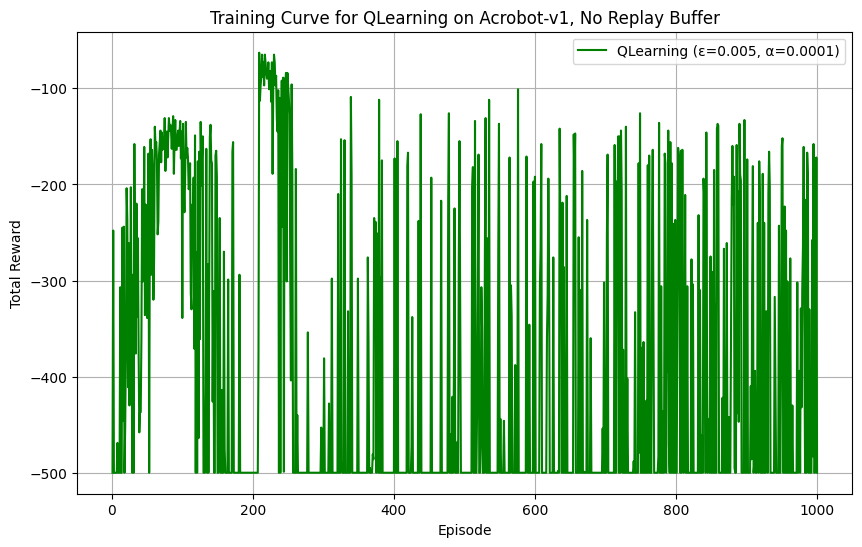

In [ ]:
num_episodes = 1000
epsilon = 0.05
step_size = 0.001  # learning rate

# Create the environment (with new_step_api)
env = gym.make("Acrobot-v1", new_step_api=True)

# Instantiate the QLearningAgent with replay buffer settings
agent = QLearningAgent(env, alpha=step_size, gamma=0.99, epsilon=epsilon, normalize_state=True)

# Run training for a single trial with checkpointing
rewards = train_agent(agent, env, num_episodes=num_episodes)

# Plot the training curve
episodes = np.arange(1, num_episodes + 1)
plt.figure(figsize=(10, 6))
plt.plot(episodes, rewards, label=f"QLearning (ε={epsilon}, α={step_size})", color="green")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Training Curve for QLearning on Acrobot-v1, No Replay Buffer") ### No Buffer!!
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# epsilon greedy policy params
# epsilons = [0.2, 0.1, 0.05]
# step_sizes = [0.01, 0.001, 0.0001]

epsilons = [0.05, 0.1, 0.2]
step_sizes = [0.0001, 0.001, 0.01]

# run params
num_trials = 10
num_episodes = 1000

### Q-learning Acrobot-v1 ###

# initialise environment
env = gym.make("Acrobot-v1", new_step_api=True)
# env = gym.make("Acrobot-v1", new_step_API=True, render_mode="human")

env_name = "Acrobot-v1"
algorithm = "QLearning"
buffer_option = "NoReplay"

# initialise results
q_agent_acrobot_results = np.zeros((len(epsilons), len(step_sizes), num_trials, num_episodes))

# run experiments
for i, epsilon in enumerate(epsilons):
    for j, step_size in enumerate(step_sizes):
        print(f"Running Experiment for Epsilon = {epsilon}, Step Size = {step_size}")
        for trial in range(num_trials):
            agent = QLearningAgent(env, alpha=step_size, gamma=0.99, epsilon=epsilon)
            checkpoint_path = f"/content/drive/MyDrive/COMP_579_A3/results/{env_name}/{algorithm}_{buffer_option}/checkpoint_eps-{epsilon}_alpha-{step_size}_trial-{trial}.pt"
            rewards = train_agent_with_checkpoint(agent, env, num_episodes,
                                                  checkpoint_path=checkpoint_path,
                                                  checkpoint_interval=500)
            q_agent_acrobot_results[i, j, trial, :] = np.array(rewards)
            save_results(rewards, algorithm, env_name, buffer_option, epsilon, step_size, trial)
            print(f"Completed Trial {trial+1} for Epsilon = {epsilon}, Step Size = {step_size}")

# Save overall results for this configuration (optional)
np.save(f"/content/drive/MyDrive/COMP_579_A3/results/{env_name}/{algorithm}_{buffer_option}_overall.npy", q_agent_acrobot_results)


Running Experiment for Epsilon = 0.05, Step Size = 0.0001
Using device: cpu
Resuming training from episode 1000


Episodes: 100%|██████████| 1000/1000 [00:00<?, ?it/s]


Saved results to /content/drive/MyDrive/COMP_579_A3/results/Acrobot-v1/QLearning_NoReplay/QLearning_Acrobot-v1_NoReplay_eps-0.05_alpha-0.0001_trial-0.npy
Completed Trial 1 for Epsilon = 0.05, Step Size = 0.0001
Using device: cpu
Resuming training from episode 1000


Episodes: 100%|██████████| 1000/1000 [00:00<?, ?it/s]


Saved results to /content/drive/MyDrive/COMP_579_A3/results/Acrobot-v1/QLearning_NoReplay/QLearning_Acrobot-v1_NoReplay_eps-0.05_alpha-0.0001_trial-1.npy
Completed Trial 2 for Epsilon = 0.05, Step Size = 0.0001
Using device: cpu
Resuming training from episode 1000


...

Checkpoint saved at episode 1000
Saved results to /content/drive/MyDrive/COMP_579_A3/results/Acrobot-v1/QLearning_NoReplay/QLearning_Acrobot-v1_NoReplay_eps-0.25_alpha-0.01_trial-3.npy
Completed Trial 4 for Epsilon = 0.25, Step Size = 0.01
Using device: cpu
Starting new training run.


Ep 500: Reward = -500.0:  50%|█████     | 500/1000 [05:48<06:43,  1.24it/s]

Checkpoint saved at episode 500


Ep 1000: Reward = -500.0: 100%|██████████| 1000/1000 [12:18<00:00,  1.35it/s]

Checkpoint saved at episode 1000
Saved results to /content/drive/MyDrive/COMP_579_A3/results/Acrobot-v1/QLearning_NoReplay/QLearning_Acrobot-v1_NoReplay_eps-0.25_alpha-0.01_trial-4.npy
Completed Trial 5 for Epsilon = 0.25, Step Size = 0.01


# PASTE CELL WHEN DONE

Acrobot v1 - Expected SARSA

Using device: cpu


Ep 1000: Reward = -177.0: 100%|██████████| 1000/1000 [14:40<00:00,  1.14it/s]


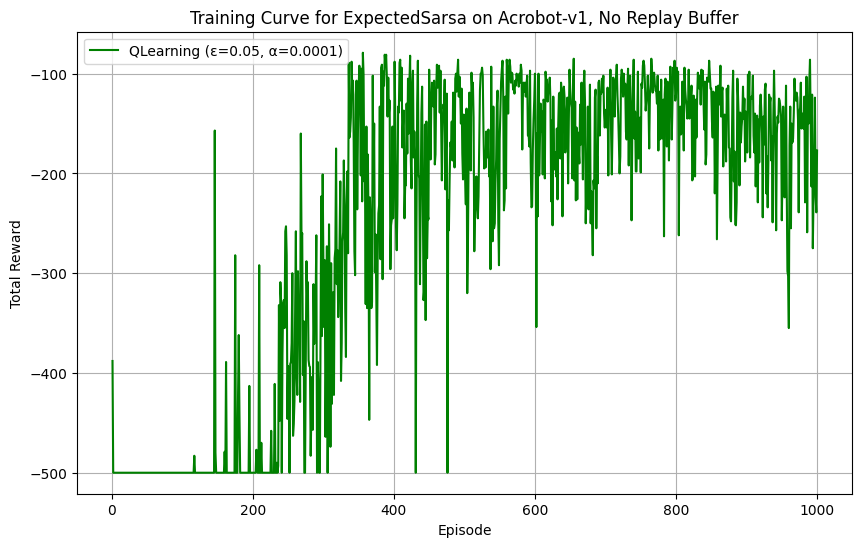

In [ ]:
num_episodes = 1000
epsilon = 0.05
step_size = 0.0001  # learning rate

# Create the environment (with new_step_api)
env = gym.make("Acrobot-v1", new_step_api=True)

# Instantiate the ExpectedSarsa with replay buffer settings
agent = ExpectedSarsaAgent(env, alpha=step_size, gamma=0.99, epsilon=epsilon)

# Run training for a single trial with checkpointing
rewards = train_agent(agent, env, num_episodes=num_episodes)

# Plot the training curve
episodes = np.arange(1, num_episodes + 1)
plt.figure(figsize=(10, 6))
plt.plot(episodes, rewards, label=f"QLearning (ε={epsilon}, α={step_size})", color="green")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Training Curve for ExpectedSarsa on Acrobot-v1, No Replay Buffer")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
### Expected Sarsa Acrobot-v1 ###

# epsilon greedy policy params

# epsilons = [0.2, 0.1, 0.05]
# step_sizes = [0.01, 0.001, 0.0001]

epsilons = [0.05, 0.1, 0.2]
step_sizes = [0.0001, 0.001, 0.01]

# run params
num_trials = 10
num_episodes = 1000

# initialise environment
env = gym.make("Acrobot-v1", new_step_api=True)

env_name = "Acrobot-v1"
algorithm = "ExpectedSarsa"
buffer_option = "NoReplay"

# initialise results
expected_sarsa_agent_acrobot_results = np.zeros((len(epsilons), len(step_sizes), num_trials, num_episodes))

# run experiments
for i, epsilon in enumerate(epsilons):
    for j, step_size in enumerate(step_sizes):
        print(f"Running Experiment for Epsilon = {epsilon}, Step Size = {step_size}")
        for trial in range(num_trials):
            agent = ExpectedSarsaAgent(env, alpha=step_size, gamma=0.99, epsilon=epsilon)
            checkpoint_path = f"/content/drive/MyDrive/COMP_579_A3/results/{env_name}/{algorithm}_{buffer_option}/checkpoint_eps-{epsilon}_alpha-{step_size}_trial-{trial}.pt"
            rewards = train_agent_with_checkpoint(agent, env, num_episodes,
                                                  checkpoint_path=checkpoint_path,
                                                  checkpoint_interval=500)
            expected_sarsa_agent_acrobot_results[i, j, trial, :] = np.array(rewards)
            save_results(rewards, algorithm, env_name, buffer_option, epsilon, step_size, trial)
            print(f"Completed Trial {trial+1} for Epsilon = {epsilon}, Step Size = {step_size}")

# Save overall results for this configuration (optional)
np.save(f"/content/drive/MyDrive/COMP_579_A3/results/{env_name}/{algorithm}_{buffer_option}_overall.npy", expected_sarsa_agent_acrobot_results)


Running Experiment for Epsilon = 0.05, Step Size = 0.0001
Using device: cpu
Resuming training from episode 1000


Episodes: 100%|██████████| 1000/1000 [00:00<?, ?it/s]

Saved results to /content/drive/MyDrive/COMP_579_A3/results/Acrobot-v1/ExpectedSarsa_NoReplay/ExpectedSarsa_Acrobot-v1_NoReplay_eps-0.05_alpha-0.0001_trial-0.npy
Completed Trial 1 for Epsilon = 0.05, Step Size = 0.0001
Using device: cpu


Resuming training from episode 1000


Episodes: 100%|██████████| 1000/1000 [00:00<?, ?it/s]


...

Checkpoint saved at episode 1000
Saved results to /content/drive/MyDrive/COMP_579_A3/results/Acrobot-v1/ExpectedSarsa_NoReplay/ExpectedSarsa_Acrobot-v1_NoReplay_eps-0.2_alpha-0.01_trial-3.npy
Completed Trial 4 for Epsilon = 0.2, Step Size = 0.01
Using device: cpu
Starting new training run.


Ep 500: Reward = -500.0:  50%|█████     | 500/1000 [06:58<07:22,  1.13it/s]

Checkpoint saved at episode 500


Ep 1000: Reward = -500.0: 100%|██████████| 1000/1000 [14:21<00:00,  1.16it/s]

Checkpoint saved at episode 1000
Saved results to /content/drive/MyDrive/COMP_579_A3/results/Acrobot-v1/ExpectedSarsa_NoReplay/ExpectedSarsa_Acrobot-v1_NoReplay_eps-0.2_alpha-0.01_trial-4.npy
Completed Trial 5 for Epsilon = 0.2, Step Size = 0.01


ALE/Assault-ram-v5 - Q-Learning

Using device: cpu


Ep 1000: Reward = 252.0: 100%|██████████| 1000/1000 [21:34<00:00,  1.29s/it]


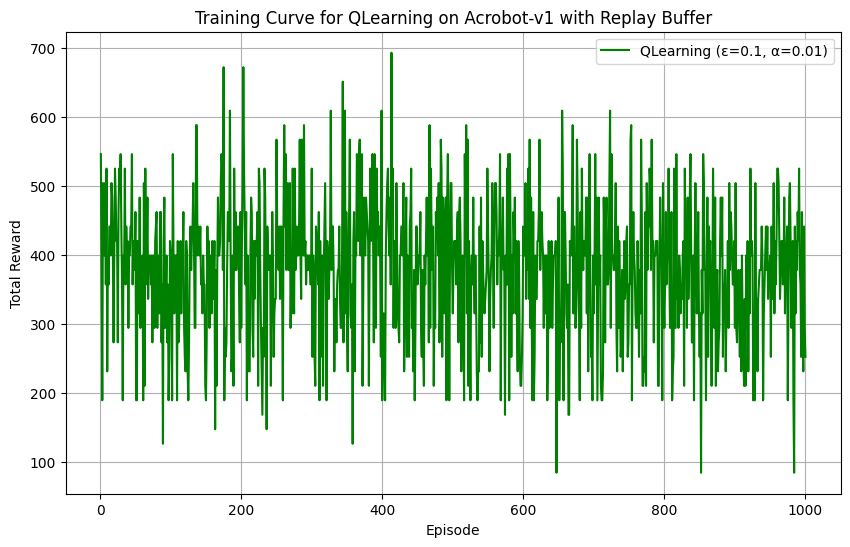

In [ ]:
num_episodes = 1000
epsilon = 0.1
step_size = 0.01  # learning rate

# Create the environment (with new_step_api)
env = gym.make("ALE/Assault-ram-v5")

# Instantiate the QLearningAgent with replay buffer settings
agent = QLearningAgent(env, alpha=step_size, gamma=0.99, epsilon=epsilon)

# Run training for a single trial with checkpointing
rewards = train_agent(agent, env, num_episodes=num_episodes)

# Plot the training curve
episodes = np.arange(1, num_episodes + 1)
plt.figure(figsize=(10, 6))
plt.plot(episodes, rewards, label=f"QLearning (ε={epsilon}, α={step_size})", color="green")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Training Curve for QLearning on Acrobot-v1 with Replay Buffer")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# epsilon greedy policy params
epsilons = [0.2, 0.1, 0.05]
step_sizes = [0.01, 0.001, 0.0001]

# run params
num_trials = 10
num_episodes = 1000

# initialise environment
env = gym.make("ALE/Assault-ram-v5")

env_name = "Assault-ram-v5"
algorithm = "QLearning"
buffer_option = "NoReplay"

# initialise results
q_agent_ale_results = np.zeros((len(epsilons), len(step_sizes), num_trials, num_episodes))

# run experiments
for i, epsilon in enumerate(epsilons):
    for j, step_size in enumerate(step_sizes):
        print(f"Running Experiment for Epsilon = {epsilon}, Step Size = {step_size}")
        for trial in range(num_trials):
            agent = QLearningAgent(env, alpha=step_size, gamma=0.99, epsilon=epsilon)
            checkpoint_path = f"/content/drive/MyDrive/COMP_579_A3/results/{env_name}/{algorithm}_{buffer_option}/checkpoint_eps-{epsilon}_alpha-{step_size}_trial-{trial}.pt"
            rewards = train_agent_with_checkpoint(agent, env, num_episodes,
                                                  checkpoint_path=checkpoint_path,
                                                  checkpoint_interval=500)
            q_agent_ale_results[i, j, trial, :] = np.array(rewards)
            save_results(rewards, algorithm, env_name, buffer_option, epsilon, step_size, trial)
            print(f"Completed Trial {trial+1} for Epsilon = {epsilon}, Step Size = {step_size}")

# Save overall results for this configuration (optional)
np.save(f"/content/drive/MyDrive/COMP_579_A3/results/{env_name}/{algorithm}_{buffer_option}_overall.npy", q_agent_ale_results)


Running Experiment for Epsilon = 0.2, Step Size = 0.01
Using device: cpu
Resuming training from episode 1000


Episodes: 100%|██████████| 1000/1000 [00:00<?, ?it/s]


Saved results to /content/drive/MyDrive/COMP_579_A3/results/Assault-ram-v5/QLearning_NoReplay/QLearning_Assault-ram-v5_NoReplay_eps-0.2_alpha-0.01_trial-0.npy
Completed Trial 1 for Epsilon = 0.2, Step Size = 0.01
Using device: cpu
Resuming training from episode 1000


Episodes: 100%|██████████| 1000/1000 [00:00<?, ?it/s]


Saved results to /content/drive/MyDrive/COMP_579_A3/results/Assault-ram-v5/QLearning_NoReplay/QLearning_Assault-ram-v5_NoReplay_eps-0.2_alpha-0.01_trial-1.npy
Completed Trial 2 for Epsilon = 0.2, Step Size = 0.01
Using device: cpu
Resuming training from episode 1000


...

Saved results to /content/drive/MyDrive/COMP_579_A3/results/Assault-ram-v5/QLearning_NoReplay/QLearning_Assault-ram-v5_NoReplay_eps-0.05_alpha-0.0001_trial-7.npy
Completed Trial 8 for Epsilon = 0.05, Step Size = 0.0001
Using device: cpu
Resuming training from episode 1000


Episodes: 100%|██████████| 1000/1000 [00:00<?, ?it/s]


Saved results to /content/drive/MyDrive/COMP_579_A3/results/Assault-ram-v5/QLearning_NoReplay/QLearning_Assault-ram-v5_NoReplay_eps-0.05_alpha-0.0001_trial-8.npy
Completed Trial 9 for Epsilon = 0.05, Step Size = 0.0001
Using device: cpu
Resuming training from episode 500


Ep 1000: Reward = 168.0: 100%|██████████| 1000/1000 [11:05<00:00,  1.33s/it]

Checkpoint saved at episode 1000
Saved results to /content/drive/MyDrive/COMP_579_A3/results/Assault-ram-v5/QLearning_NoReplay/QLearning_Assault-ram-v5_NoReplay_eps-0.05_alpha-0.0001_trial-9.npy
Completed Trial 10 for Epsilon = 0.05, Step Size = 0.0001


ALE/Assault-ram-v5 - Expected SARSA

Using device: cpu


Ep 1000: Reward = 357.0: 100%|██████████| 1000/1000 [18:58<00:00,  1.14s/it]


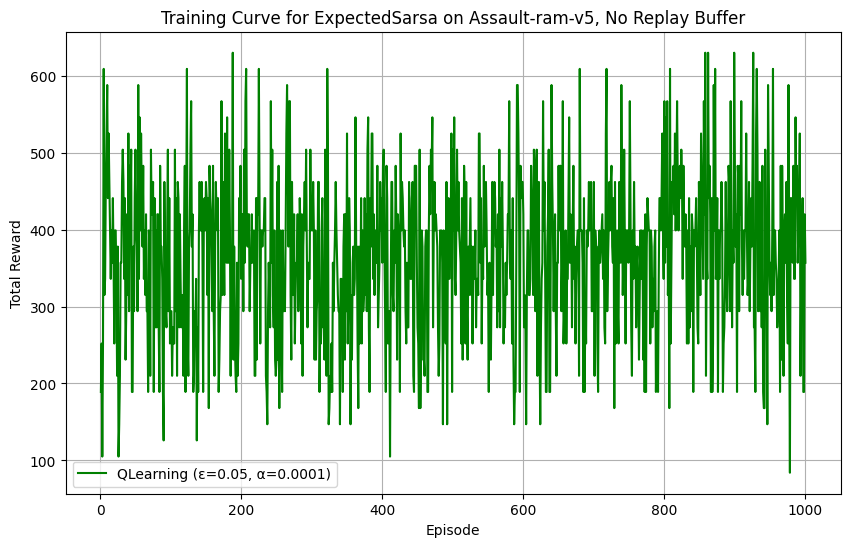

In [ ]:
num_episodes = 1000
epsilon = 0.05
step_size = 0.0001  # learning rate

# Create the environment (with new_step_api)
env = gym.make("ALE/Assault-ram-v5", obs_type="ram")

# Instantiate the ExpectedSarsa with replay buffer settings
agent = ExpectedSarsaAgent(env, alpha=step_size, gamma=0.99, epsilon=epsilon)

# Run training for a single trial with checkpointing
rewards = train_agent(agent, env, num_episodes=num_episodes)

# Plot the training curve
episodes = np.arange(1, num_episodes + 1)
plt.figure(figsize=(10, 6))
plt.plot(episodes, rewards, label=f"QLearning (ε={epsilon}, α={step_size})", color="green")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Training Curve for ExpectedSarsa on Assault-ram-v5, No Replay Buffer")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# epsilon greedy policy params
epsilons = [0.2, 0.1, 0.05]
step_sizes = [0.01, 0.001, 0.0001]

# run params
num_trials = 10
num_episodes = 1000

# initialise environment
env = gym.make("ALE/Assault-ram-v5")

env_name = "Assault-ram-v5"
algorithm = "ExpectedSarsa"
buffer_option = "NoReplay"

# initialise results
expected_sarsa_agent_ale_results = np.zeros((len(epsilons), len(step_sizes), num_trials, num_episodes))

# run experiments
for i, epsilon in enumerate(epsilons):
    for j, step_size in enumerate(step_sizes):
        print(f"Running Experiment for Epsilon = {epsilon}, Step Size = {step_size}")
        for trial in range(num_trials):
            agent = ExpectedSarsaAgent(env, alpha=step_size, gamma=0.99, epsilon=epsilon)
            checkpoint_path = f"/content/drive/MyDrive/COMP_579_A3/results/{env_name}/{algorithm}_{buffer_option}/checkpoint_eps-{epsilon}_alpha-{step_size}_trial-{trial}.pt"
            rewards = train_agent_with_checkpoint(agent, env, num_episodes,
                                                  checkpoint_path=checkpoint_path,
                                                  checkpoint_interval=500)
            expected_sarsa_agent_ale_results[i, j, trial, :] = np.array(rewards)
            save_results(rewards, algorithm, env_name, buffer_option, epsilon, step_size, trial)
            print(f"Completed Trial {trial+1} for Epsilon = {epsilon}, Step Size = {step_size}")

# Save overall results for this configuration (optional)
np.save(f"/content/drive/MyDrive/COMP_579_A3/results/{env_name}/{algorithm}_{buffer_option}_overall.npy", expected_sarsa_agent_ale_results)

Running Experiment for Epsilon = 0.2, Step Size = 0.01
Using device: cpu
Resuming training from episode 1000


Episodes: 100%|██████████| 1000/1000 [00:00<?, ?it/s]


Saved results to /content/drive/MyDrive/COMP_579_A3/results/Assault-ram-v5/ExpectedSarsa_NoReplay/ExpectedSarsa_Assault-ram-v5_NoReplay_eps-0.2_alpha-0.01_trial-0.npy
Completed Trial 1 for Epsilon = 0.2, Step Size = 0.01
Using device: cpu
Resuming training from episode 1000


Episodes: 100%|██████████| 1000/1000 [00:00<?, ?it/s]


Saved results to /content/drive/MyDrive/COMP_579_A3/results/Assault-ram-v5/ExpectedSarsa_NoReplay/ExpectedSarsa_Assault-ram-v5_NoReplay_eps-0.2_alpha-0.01_trial-1.npy
Completed Trial 2 for Epsilon = 0.2, Step Size = 0.01
Using device: cpu
Resuming training from episode 1000


...

Checkpoint saved at episode 1000
Saved results to /content/drive/MyDrive/COMP_579_A3/results/Assault-ram-v5/ExpectedSarsa_NoReplay/ExpectedSarsa_Assault-ram-v5_NoReplay_eps-0.05_alpha-0.0001_trial-8.npy
Completed Trial 9 for Epsilon = 0.05, Step Size = 0.0001
Using device: cpu
Starting new training run.


Ep 500: Reward = 357.0:  50%|█████     | 500/1000 [09:03<08:42,  1.05s/it]

Checkpoint saved at episode 500


Ep 1000: Reward = 294.0: 100%|██████████| 1000/1000 [17:53<00:00,  1.07s/it]

Checkpoint saved at episode 1000
Saved results to /content/drive/MyDrive/COMP_579_A3/results/Assault-ram-v5/ExpectedSarsa_NoReplay/ExpectedSarsa_Assault-ram-v5_NoReplay_eps-0.05_alpha-0.0001_trial-9.npy
Completed Trial 10 for Epsilon = 0.05, Step Size = 0.0001


### 1.4 - Repeat Using Replay Buffer

Acrobot-v1 - Q-Learning with Buffer

Using device: cpu


Ep 1000: Reward = -110.0: 100%|██████████| 1000/1000 [03:22<00:00,  4.95it/s]


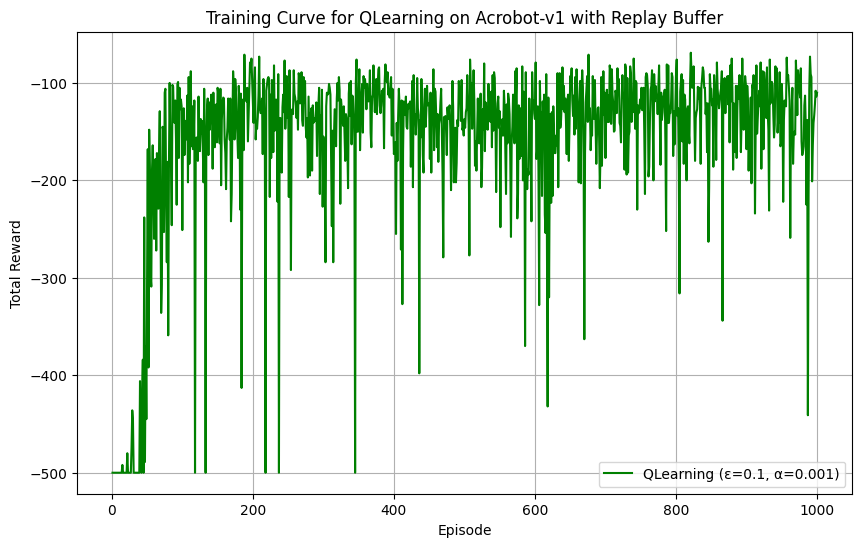

In [ ]:
num_episodes = 1000
epsilon = 0.1
step_size = 0.001  # learning rate

# Create the environment (with new_step_api)
env = gym.make("Acrobot-v1", new_step_api=True)

# Instantiate the QLearningAgent with replay buffer settings
agent = QLearningAgent(env, alpha=step_size, gamma=0.99, epsilon=epsilon)

# Run training for a single trial with checkpointing
rewards = train_agent_with_replay(agent, env, num_episodes=num_episodes,
                                             batch_size=32,
                                             start_training=1000,
                                             update_every=4)

# Plot the training curve
episodes = np.arange(1, num_episodes + 1)
plt.figure(figsize=(10, 6))
plt.plot(episodes, rewards, label=f"QLearning (ε={epsilon}, α={step_size})", color="green")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Training Curve for QLearning on Acrobot-v1 with Replay Buffer")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# epsilon greedy policy params
epsilons = [0.1, 0.2, 0.05]
step_sizes = [0.001, 0.01, 0.0001]

# run params
num_trials = 10
num_episodes = 1000

# initialise environment
env = gym.make("Acrobot-v1", new_step_api=True)

env_name = "Acrobot-v1"
algorithm = "QLearning"
buffer_option = "Replay"

# initialise results
q_agent_acrobot_replay_results = np.zeros((len(epsilons), len(step_sizes), num_trials, num_episodes))

# run experiments
for i, epsilon in enumerate(epsilons):
    for j, step_size in enumerate(step_sizes):
        print(f"Running Replay Experiment for Epsilon = {epsilon}, Step Size = {step_size}")
        for trial in range(num_trials):
            agent = QLearningAgent(env, alpha=step_size, gamma=0.99, epsilon=epsilon)
            checkpoint_path = f"/content/drive/MyDrive/COMP_579_A3/results/{env_name}/{algorithm}_{buffer_option}/checkpoint_eps-{epsilon}_alpha-{step_size}_trial-{trial}.pt"
            rewards = train_agent_with_replay_checkpoint(agent, env, num_episodes,
                                                         batch_size=32,
                                                         start_training=1000,
                                                         update_every=4,
                                                         checkpoint_path=checkpoint_path,
                                                         checkpoint_interval=500)
            q_agent_acrobot_replay_results[i, j, trial, :] = np.array(rewards)
            save_results(rewards, algorithm, env_name, buffer_option, epsilon, step_size, trial)
            print(f"Completed Replay Trial {trial+1} for Epsilon = {epsilon}, Step Size = {step_size}")

# Optionally, save overall results
# np.save(f"results/{env_name}/{algorithm}_{buffer_option}_overall.npy", q_agent_acrobot_replay_results)


Running Replay Experiment for Epsilon = 0.1, Step Size = 0.001
Using device: cpu
Starting new replay training run.


Ep 501: Reward = -75.0, Loss = 34.39017418026924:  50%|█████     | 501/1000 [02:15<05:12,  1.59it/s]

Checkpoint saved at episode 500


Ep 1000: Reward = -127.0, Loss = 78.04191756248474: 100%|██████████| 1000/1000 [04:01<00:00,  4.14it/s]


Checkpoint saved at episode 1000
Saved results to /content/drive/MyDrive/COMP_579_A3/results/Acrobot-v1/QLearning_Replay/QLearning_Acrobot-v1_Replay_eps-0.1_alpha-0.001_trial-0.npy
Completed Replay Trial 1 for Epsilon = 0.1, Step Size = 0.001
Using device: cpu
Starting new replay training run.


...

Ep 500: Reward = -293.0, Loss = 739.4445430338383:  50%|█████     | 500/1000 [05:11<12:50,  1.54s/it]

Checkpoint saved at episode 500


Ep 1000: Reward = -71.0, Loss = 297.73555532097816: 100%|██████████| 1000/1000 [06:46<00:00,  2.46it/s]

Checkpoint saved at episode 1000
Saved results to /content/drive/MyDrive/COMP_579_A3/results/Acrobot-v1/QLearning_Replay/QLearning_Acrobot-v1_Replay_eps-0.05_alpha-0.0001_trial-9.npy
Completed Replay Trial 10 for Epsilon = 0.05, Step Size = 0.0001


FileNotFoundError: [Errno 2] No such file or directory: 'results/Acrobot-v1/QLearning_Replay_overall.npy'

Acrobot-v1 - Expected SARSA with Buffer

Using device: cpu


Ep 1000: Reward = -109.0: 100%|██████████| 1000/1000 [04:31<00:00,  3.68it/s]


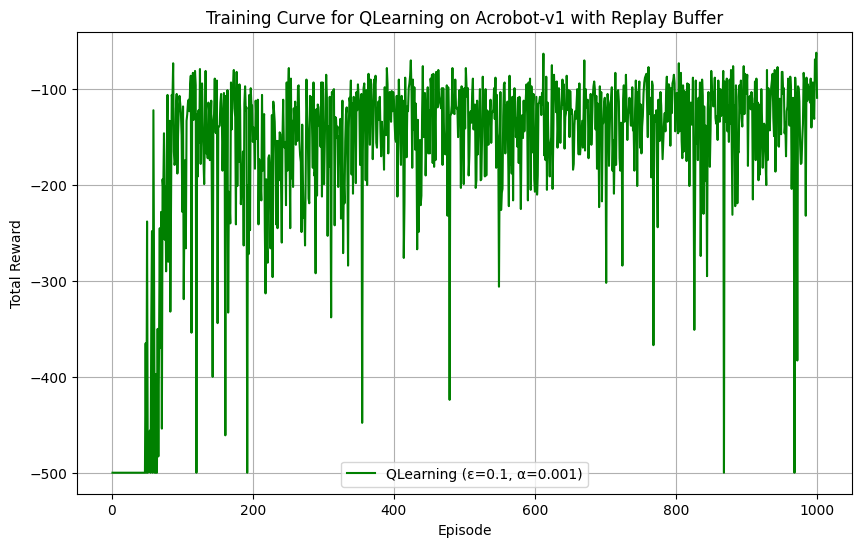

In [ ]:
num_episodes = 1000
epsilon = 0.1
step_size = 0.001  # learning rate

# Create the environment (with new_step_api)
env = gym.make("Acrobot-v1", new_step_api=True)

# Instantiate the QLearningAgent with replay buffer settings
agent = ExpectedSarsaAgent(env, alpha=step_size, gamma=0.99, epsilon=epsilon)

# Run training for a single trial with checkpointing
rewards = train_agent_with_replay(agent, env, num_episodes=num_episodes,
                                             batch_size=32,
                                             start_training=1000,
                                             update_every=4)

# Plot the training curve
episodes = np.arange(1, num_episodes + 1)
plt.figure(figsize=(10, 6))
plt.plot(episodes, rewards, label=f"QLearning (ε={epsilon}, α={step_size})", color="green")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Training Curve for QLearning on Acrobot-v1 with Replay Buffer")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# epsilon greedy policy params
epsilons = [0.1, 0.2, 0.05]
step_sizes = [0.001, 0.01, 0.0001]

# run params
num_trials = 10
num_episodes = 1000

# initialise environment
env = gym.make("Acrobot-v1", new_step_api=True)

env_name = "Acrobot-v1"
algorithm = "ExpectedSarsa"
buffer_option = "Replay"

# initialise results
expected_sarsa_agent_acrobot_replay_results = np.zeros((len(epsilons), len(step_sizes), num_trials, num_episodes))

# run experiments
for i, epsilon in enumerate(epsilons):
    for j, step_size in enumerate(step_sizes):
        print(f"Running Replay Experiment for Epsilon = {epsilon}, Step Size = {step_size}")
        for trial in range(num_trials):
            agent = ExpectedSarsaAgent(env, alpha=step_size, gamma=0.99, epsilon=epsilon)
            checkpoint_path = f"/content/drive/MyDrive/COMP_579_A3/results/{env_name}/{algorithm}_{buffer_option}/checkpoint_eps-{epsilon}_alpha-{step_size}_trial-{trial}.pt"
            rewards = train_agent_with_replay_checkpoint(agent, env, num_episodes,
                                                         batch_size=32,
                                                         start_training=1000,
                                                         update_every=4,
                                                         checkpoint_path=checkpoint_path,
                                                         checkpoint_interval=500)
            expected_sarsa_agent_acrobot_replay_results[i, j, trial, :] = np.array(rewards)
            save_results(rewards, algorithm, env_name, buffer_option, epsilon, step_size, trial)
            print(f"Completed Replay Trial {trial+1} for Epsilon = {epsilon}, Step Size = {step_size}")

# Optionally, save overall results
np.save(f"/content/drive/MyDrive/COMP_579_A3/results/{env_name}/{algorithm}_{buffer_option}_overall.npy", expected_sarsa_agent_acrobot_replay_results)

Running Replay Experiment for Epsilon = 0.1, Step Size = 0.001
Using device: cpu
Resuming replay training from episode 1000


Episodes: 100%|██████████| 1000/1000 [00:00<?, ?it/s]


Saved results to /content/drive/MyDrive/COMP_579_A3/results/Acrobot-v1/ExpectedSarsa_Replay/ExpectedSarsa_Acrobot-v1_Replay_eps-0.1_alpha-0.001_trial-0.npy
Completed Replay Trial 1 for Epsilon = 0.1, Step Size = 0.001
Using device: cpu
Resuming replay training from episode 1000


Episodes: 100%|██████████| 1000/1000 [00:00<?, ?it/s]

Saved results to /content/drive/MyDrive/COMP_579_A3/results/Acrobot-v1/ExpectedSarsa_Replay/ExpectedSarsa_Acrobot-v1_Replay_eps-0.1_alpha-0.001_trial-1.npy
Completed Replay Trial 2 for Epsilon = 0.1, Step Size = 0.001
Using device: cpu


...

Checkpoint saved at episode 1000
Saved results to /content/drive/MyDrive/COMP_579_A3/results/Acrobot-v1/ExpectedSarsa_Replay/ExpectedSarsa_Acrobot-v1_Replay_eps-0.05_alpha-0.0001_trial-8.npy
Completed Replay Trial 9 for Epsilon = 0.05, Step Size = 0.0001
Using device: cpu
Starting new replay training run.


Ep 501: Reward = -78.0, Loss = 72.98120695352554:  50%|█████     | 501/1000 [04:19<06:37,  1.26it/s]

Checkpoint saved at episode 500


Ep 1000: Reward = -99.0, Loss = 135.63857871294022: 100%|██████████| 1000/1000 [05:40<00:00,  2.94it/s]

Checkpoint saved at episode 1000
Saved results to /content/drive/MyDrive/COMP_579_A3/results/Acrobot-v1/ExpectedSarsa_Replay/ExpectedSarsa_Acrobot-v1_Replay_eps-0.05_alpha-0.0001_trial-9.npy
Completed Replay Trial 10 for Epsilon = 0.05, Step Size = 0.0001


ALE/Assault-ram-v5 - Q-Learning with Buffer

Using device: cpu


Ep 1000: Reward = 336.0: 100%|██████████| 1000/1000 [23:46<00:00,  1.43s/it]


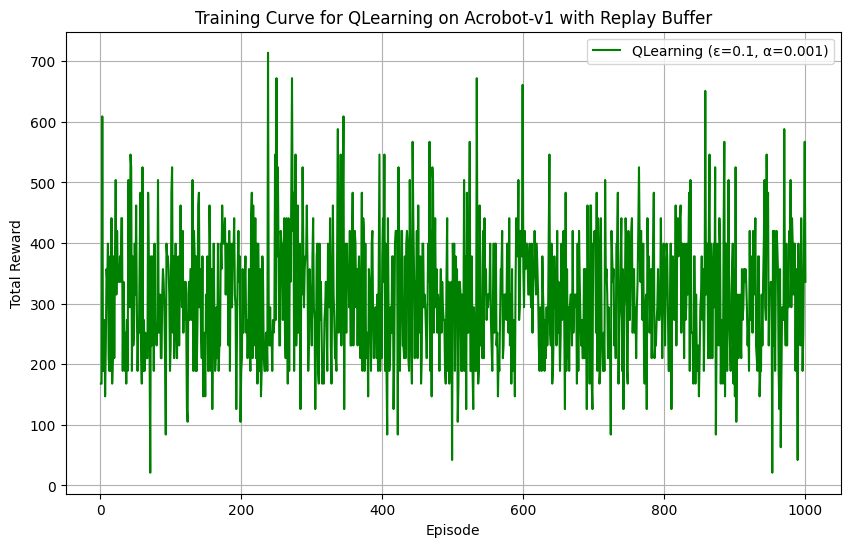

In [ ]:
num_episodes = 1000
epsilon = 0.1
step_size = 0.001  # learning rate

# Create the environment (with new_step_api)
env = gym.make("ALE/Assault-ram-v5")

# Instantiate the QLearningAgent with replay buffer settings
agent = QLearningAgent(env, alpha=step_size, gamma=0.99, epsilon=epsilon)

# Run training for a single trial with checkpointing
rewards = train_agent_with_replay(agent, env, num_episodes=num_episodes)

# Plot the training curve
episodes = np.arange(1, num_episodes + 1)
plt.figure(figsize=(10, 6))
plt.plot(episodes, rewards, label=f"QLearning (ε={epsilon}, α={step_size})", color="green")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Training Curve for QLearning on Acrobot-v1 with Replay Buffer")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# epsilon greedy policy params
epsilons = [0.2, 0.1, 0.05]
step_sizes = [0.001, 0.01, 0.0001]

# run params
num_trials = 10
num_episodes = 1000

# initialise environment
env = gym.make("ALE/Assault-ram-v5", obs_type="ram")

env_name = "Assault-ram-v5"
algorithm = "QLearning"
buffer_option = "Replay"

# initialise results
q_agent_ale_replay_results = np.zeros((len(epsilons), len(step_sizes), num_trials, num_episodes))

# run experiments
for i, epsilon in enumerate(epsilons):
    for j, step_size in enumerate(step_sizes):
        print(f"Running Replay Experiment for Epsilon = {epsilon}, Step Size = {step_size}")
        for trial in range(num_trials):
            agent = QLearningAgent(env, alpha=step_size, gamma=0.99, epsilon=epsilon)
            checkpoint_path = f"/content/drive/MyDrive/COMP_579_A3/results/{env_name}/{algorithm}_{buffer_option}/checkpoint_eps-{epsilon}_alpha-{step_size}_trial-{trial}.pt"
            rewards = train_agent_with_replay_checkpoint(agent, env, num_episodes,
                                                         batch_size=32,
                                                         start_training=1000,
                                                         update_every=4,
                                                         checkpoint_path=checkpoint_path,
                                                         checkpoint_interval=500)
            q_agent_ale_replay_results[i, j, trial, :] = np.array(rewards)
            save_results(rewards, algorithm, env_name, buffer_option, epsilon, step_size, trial)
            print(f"Completed Replay Trial {trial+1} for Epsilon = {epsilon}, Step Size = {step_size}")

# Optionally, save overall results
np.save(f"/content/drive/MyDrive/COMP_579_A3/results/{env_name}/{algorithm}_{buffer_option}_overall.npy", q_agent_ale_replay_results)

Running Replay Experiment for Epsilon = 0.2, Step Size = 0.001
Using device: cpu
Resuming replay training from episode 1000


Episodes: 100%|██████████| 1000/1000 [00:00<?, ?it/s]

Saved results to /content/drive/MyDrive/COMP_579_A3/results/Assault-ram-v5/QLearning_Replay/QLearning_Assault-ram-v5_Replay_eps-0.2_alpha-0.001_trial-0.npy
Completed Replay Trial 1 for Epsilon = 0.2, Step Size = 0.001
Using device: cpu


Resuming replay training from episode 1000


Episodes: 100%|██████████| 1000/1000 [00:00<?, ?it/s]

...

Checkpoint saved at episode 1000
Saved results to /content/drive/MyDrive/COMP_579_A3/results/Assault-ram-v5/QLearning_Replay/QLearning_Assault-ram-v5_Replay_eps-0.05_alpha-0.0001_trial-8.npy
Completed Replay Trial 9 for Epsilon = 0.05, Step Size = 0.0001
Using device: cpu
Starting new replay training run.


Ep 500: Reward = 441.0, Loss = 2066.8254640698433:  50%|█████     | 500/1000 [08:50<24:05,  2.89s/it]

Checkpoint saved at episode 500


Ep 1000: Reward = 399.0, Loss = 1848.791661605239: 100%|██████████| 1000/1000 [17:50<00:00,  1.07s/it]


Checkpoint saved at episode 1000
Saved results to /content/drive/MyDrive/COMP_579_A3/results/Assault-ram-v5/QLearning_Replay/QLearning_Assault-ram-v5_Replay_eps-0.05_alpha-0.0001_trial-9.npy
Completed Replay Trial 10 for Epsilon = 0.05, Step Size = 0.0001


ALE/Assault-ram-v5 - Expected SARSA with Buffer

Using device: cpu


Ep 1000: Reward = 252.0: 100%|██████████| 1000/1000 [14:43<00:00,  1.13it/s]


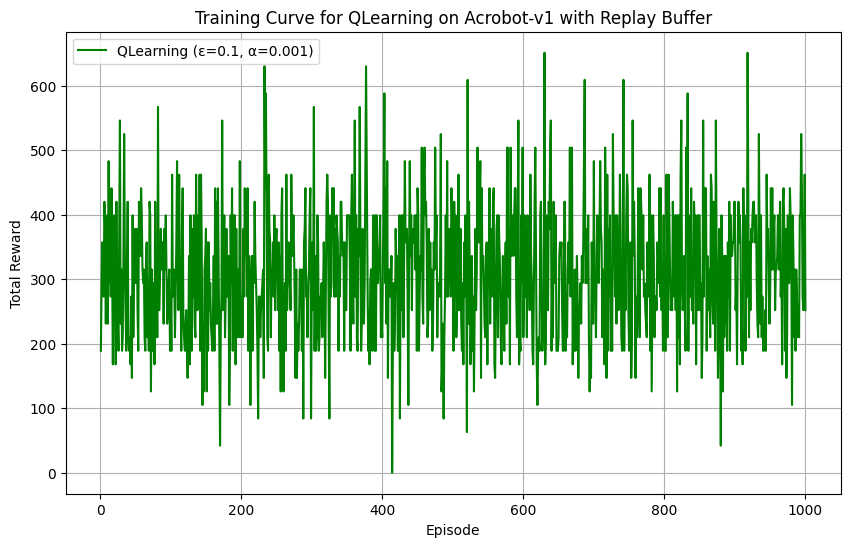

In [ ]:
num_episodes = 1000
epsilon = 0.1
step_size = 0.001  # learning rate

# Create the environment (with new_step_api)
env = gym.make("ALE/Assault-ram-v5")

# Instantiate the QLearningAgent with replay buffer settings
agent = ExpectedSarsaAgent(env, alpha=step_size, gamma=0.99, epsilon=epsilon)

# Run training for a single trial with checkpointing
rewards = train_agent_with_replay(agent, env, num_episodes=num_episodes)

# Plot the training curve
episodes = np.arange(1, num_episodes + 1)
plt.figure(figsize=(10, 6))
plt.plot(episodes, rewards, label=f"QLearning (ε={epsilon}, α={step_size})", color="green")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Training Curve for QLearning on Acrobot-v1 with Replay Buffer")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# run params
num_trials = 10
num_episodes = 1000

# epsilon greedy policy params
epsilons = [0.1, 0.2, 0.05]
step_sizes = [0.001, 0.01, 0.0001]

# initialise environment
env = gym.make("ALE/Assault-ram-v5")

env_name = "Assault-ram-v5"
algorithm = "ExpectedSarsa"
buffer_option = "Replay"

# initialise results
expected_sarsa_agent_ale_replay_results = np.zeros((len(epsilons), len(step_sizes), num_trials, num_episodes))

# run experiments
for i, epsilon in enumerate(epsilons):
    for j, step_size in enumerate(step_sizes):
        print(f"Running Replay Experiment for Epsilon = {epsilon}, Step Size = {step_size}")
        for trial in range(num_trials):
            agent = ExpectedSarsaAgent(env, alpha=step_size, gamma=0.99, epsilon=epsilon)
            checkpoint_path = f"/content/drive/MyDrive/COMP_579_A3/results/{env_name}/{algorithm}_{buffer_option}/checkpoint_eps-{epsilon}_alpha-{step_size}_trial-{trial}.pt"
            rewards = train_agent_with_replay_checkpoint(agent, env, num_episodes,
                                                         batch_size=32,
                                                         start_training=1000,
                                                         update_every=4,
                                                         checkpoint_path=checkpoint_path,
                                                         checkpoint_interval=500)
            expected_sarsa_agent_ale_replay_results[i, j, trial, :] = np.array(rewards)
            save_results(rewards, algorithm, env_name, buffer_option, epsilon, step_size, trial)
            print(f"Completed Replay Trial {trial+1} for Epsilon = {epsilon}, Step Size = {step_size}")

# Optionally, save overall results
np.save(f"/content/drive/MyDrive/COMP_579_A3/results/{env_name}/{algorithm}_{buffer_option}_overall.npy", expected_sarsa_agent_ale_replay_results)

Running Replay Experiment for Epsilon = 0.1, Step Size = 0.001
Using device: cpu
Resuming replay training from episode 1000


Episodes: 100%|██████████| 1000/1000 [00:00<?, ?it/s]


Saved results to /content/drive/MyDrive/COMP_579_A3/results/Assault-ram-v5/ExpectedSarsa_Replay/ExpectedSarsa_Assault-ram-v5_Replay_eps-0.1_alpha-0.001_trial-0.npy
Completed Replay Trial 1 for Epsilon = 0.1, Step Size = 0.001
Using device: cpu
Resuming replay training from episode 1000


Episodes: 100%|██████████| 1000/1000 [00:00<?, ?it/s]


Saved results to /content/drive/MyDrive/COMP_579_A3/results/Assault-ram-v5/ExpectedSarsa_Replay/ExpectedSarsa_Assault-ram-v5_Replay_eps-0.1_alpha-0.001_trial-1.npy
Completed Replay Trial 2 for Epsilon = 0.1, Step Size = 0.001
Using device: cpu
Resuming replay training from episode 1000


...

Checkpoint saved at episode 1000
Saved results to /content/drive/MyDrive/COMP_579_A3/results/Assault-ram-v5/ExpectedSarsa_Replay/ExpectedSarsa_Assault-ram-v5_Replay_eps-0.05_alpha-0.0001_trial-8.npy
Completed Replay Trial 9 for Epsilon = 0.05, Step Size = 0.0001
Using device: cpu
Starting new replay training run.


Ep 500: Reward = 420.0, Loss = 4116.497890330851:  50%|█████     | 500/1000 [06:05<17:43,  2.13s/it]

Checkpoint saved at episode 500


Ep 1000: Reward = 294.0, Loss = 3363.9005947187543: 100%|██████████| 1000/1000 [12:01<00:00,  1.39it/s]


Checkpoint saved at episode 1000
Saved results to /content/drive/MyDrive/COMP_579_A3/results/Assault-ram-v5/ExpectedSarsa_Replay/ExpectedSarsa_Assault-ram-v5_Replay_eps-0.05_alpha-0.0001_trial-9.npy
Completed Replay Trial 10 for Epsilon = 0.05, Step Size = 0.0001


### 1.5 - Plot Results

In [7]:
# smoothing
def smooth_curve(data, window_size=10):
    """Smooth the input data using a moving average with the given window size."""
    window = np.ones(window_size) / window_size
    return np.convolve(data, window, mode='same')

Plots according to assignment outline

Plotting for Acrobot-v1: ε=0.05, α=0.0001


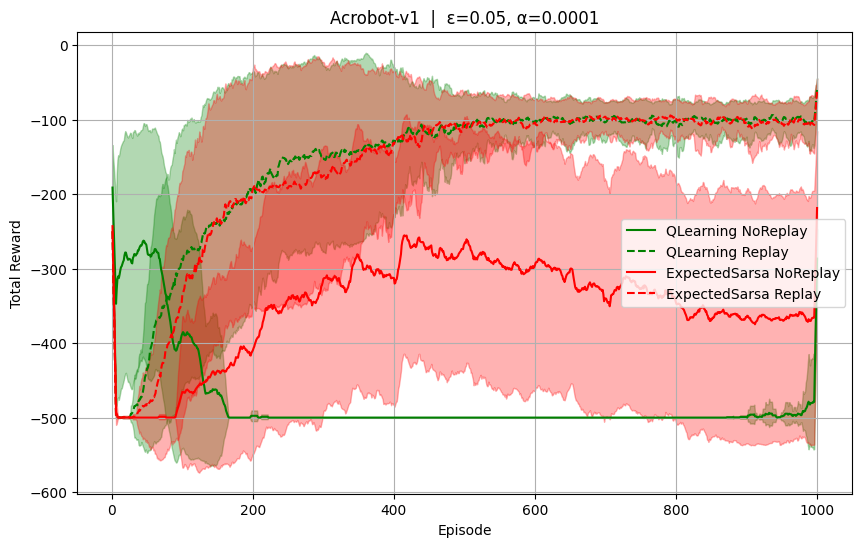

Plotting for Acrobot-v1: ε=0.05, α=0.001


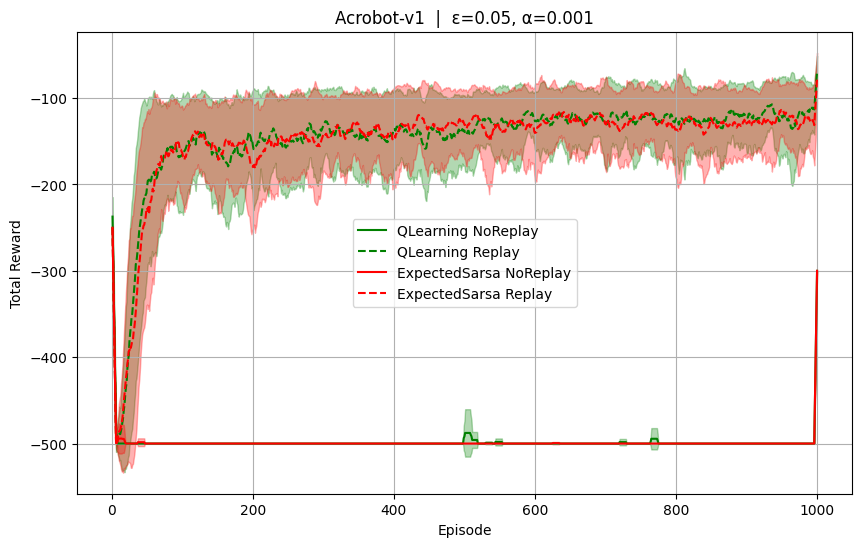

Plotting for Acrobot-v1: ε=0.05, α=0.01


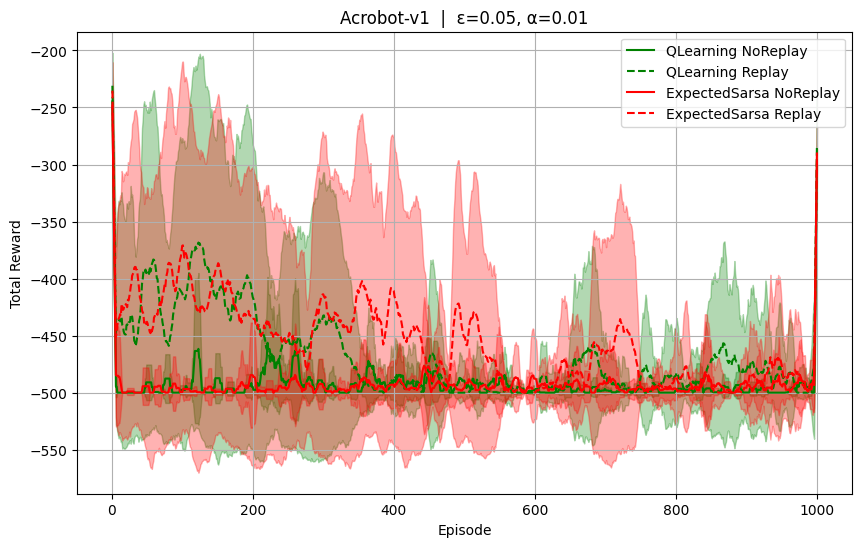

Plotting for Acrobot-v1: ε=0.1, α=0.0001


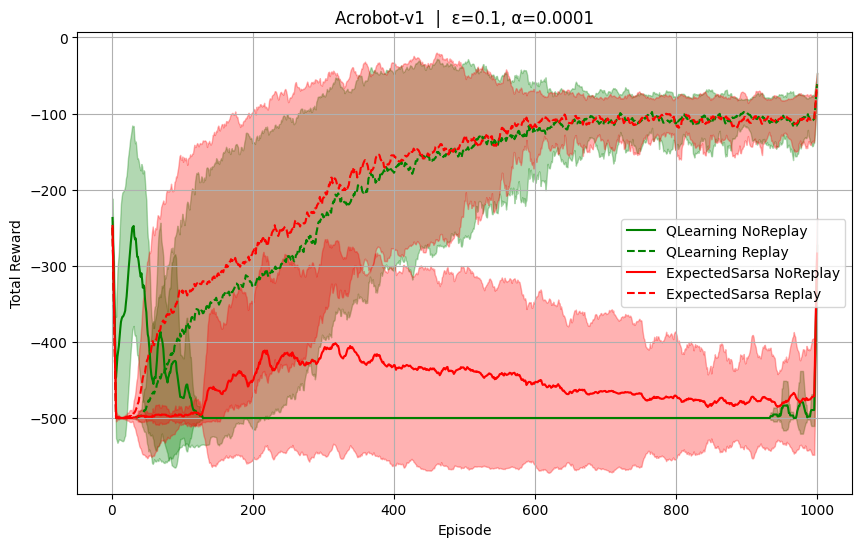

Plotting for Acrobot-v1: ε=0.1, α=0.001


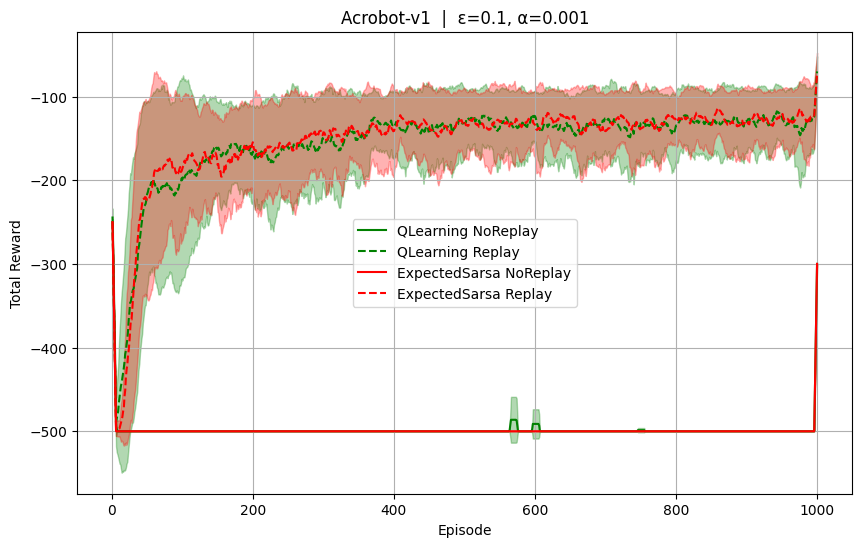

Plotting for Acrobot-v1: ε=0.1, α=0.01


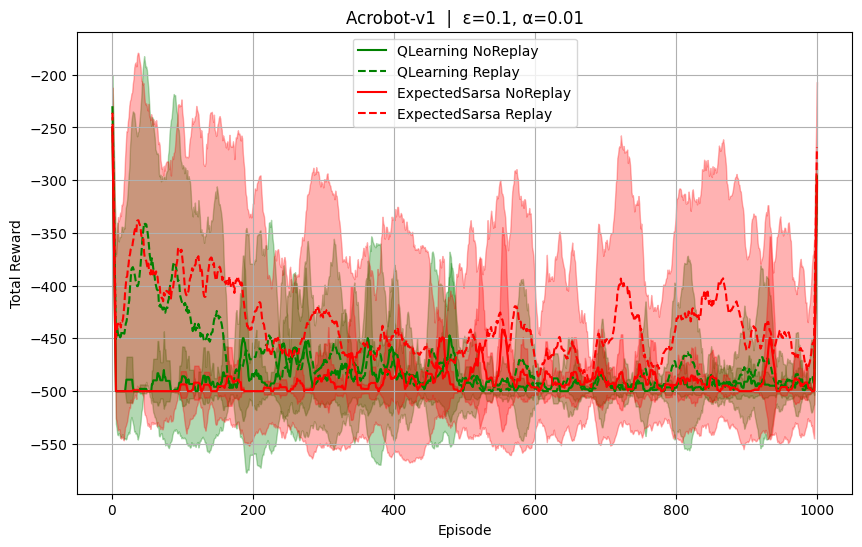

Plotting for Acrobot-v1: ε=0.2, α=0.0001


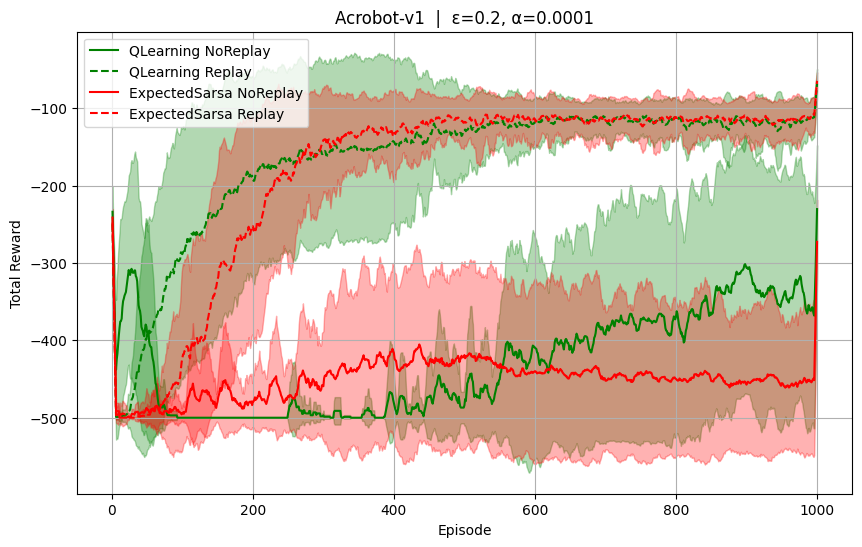

Plotting for Acrobot-v1: ε=0.2, α=0.001


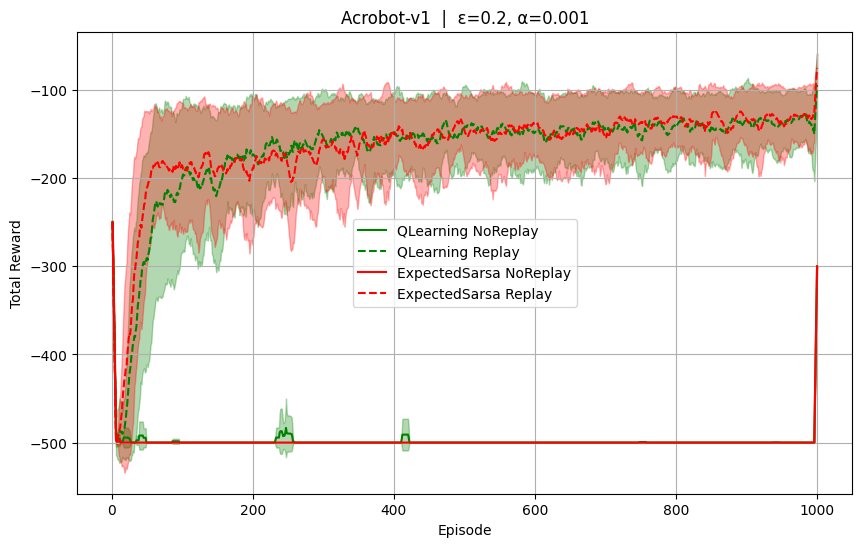

Plotting for Acrobot-v1: ε=0.2, α=0.01


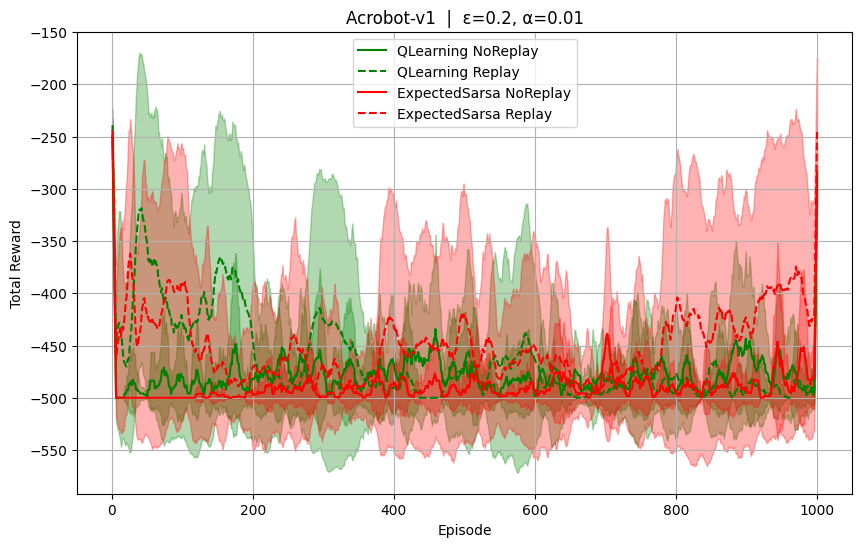

Plotting for Assault-ram-v5: ε=0.05, α=0.0001


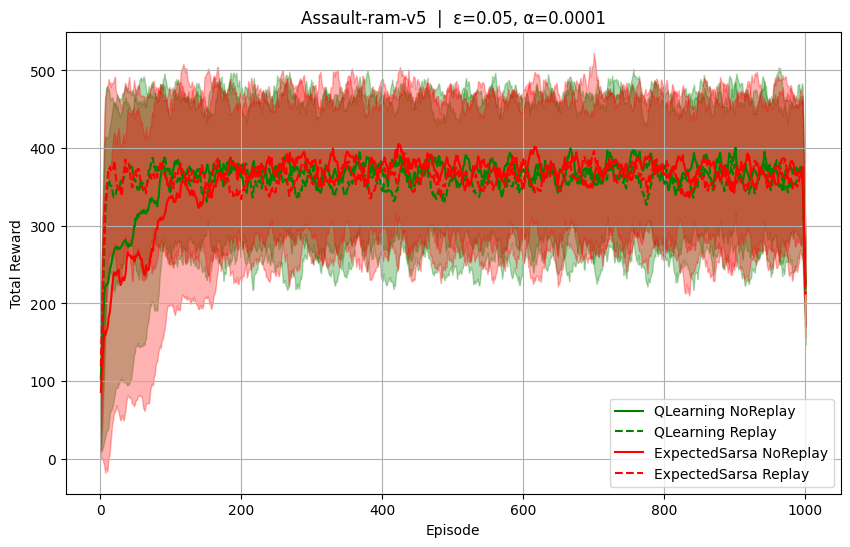

Plotting for Assault-ram-v5: ε=0.05, α=0.001


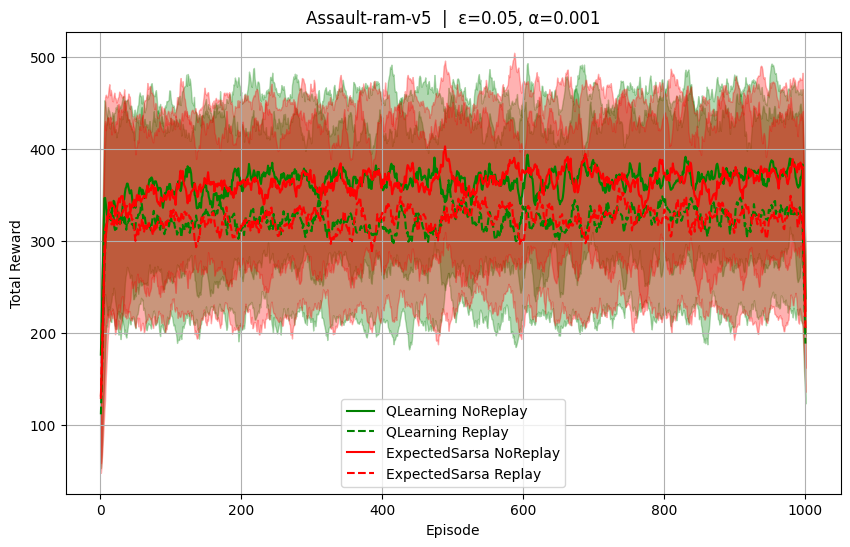

Plotting for Assault-ram-v5: ε=0.05, α=0.01


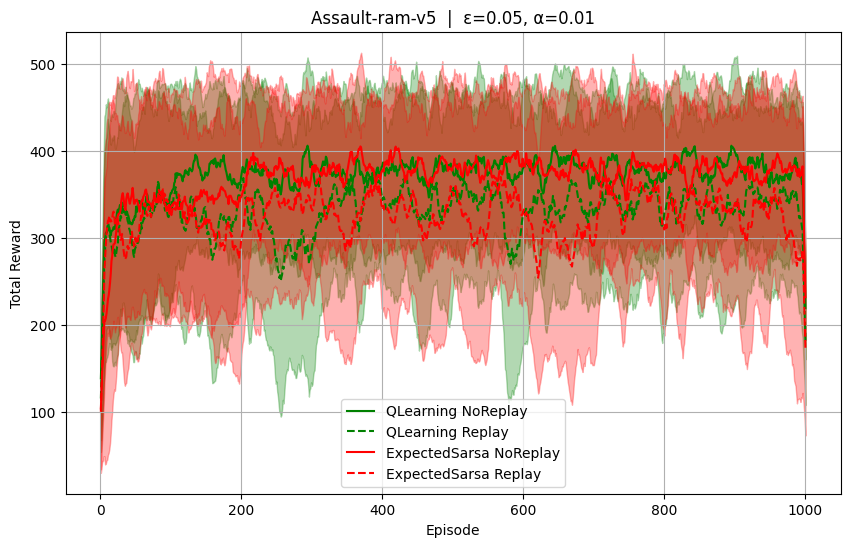

Plotting for Assault-ram-v5: ε=0.1, α=0.0001


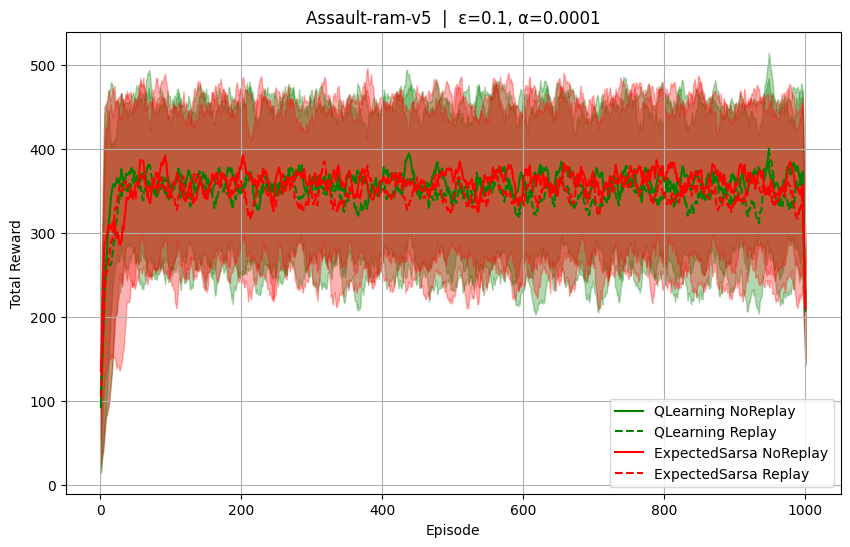

Plotting for Assault-ram-v5: ε=0.1, α=0.001


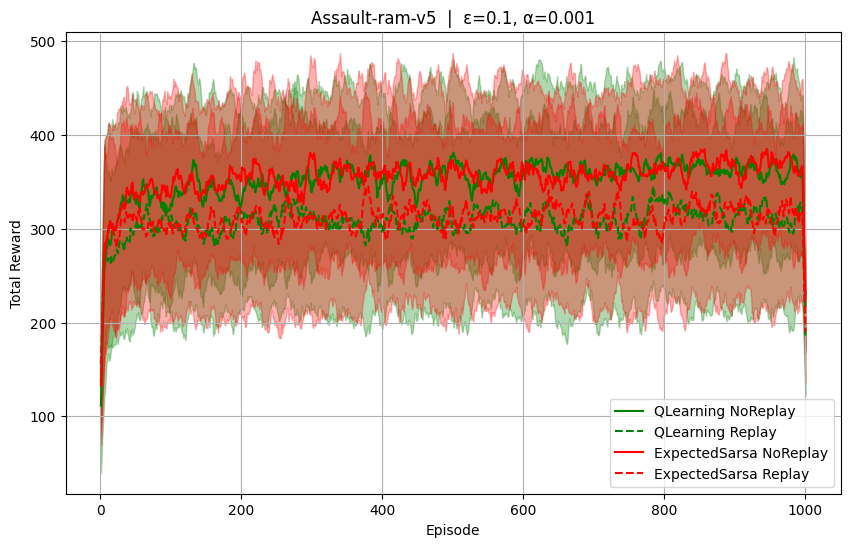

Plotting for Assault-ram-v5: ε=0.1, α=0.01


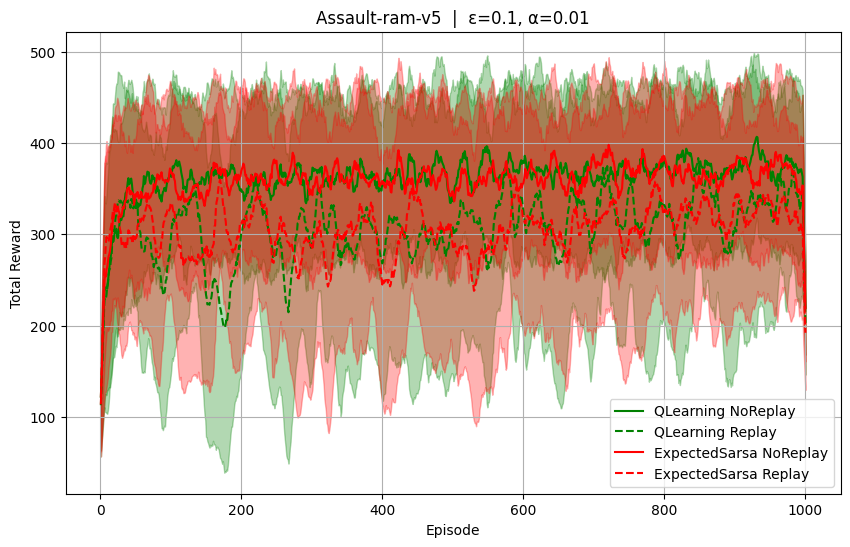

Plotting for Assault-ram-v5: ε=0.2, α=0.0001


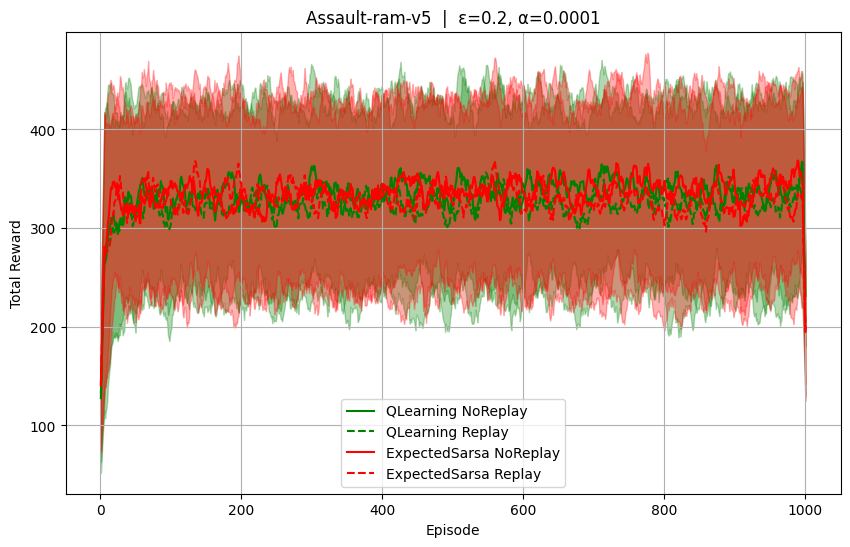

Plotting for Assault-ram-v5: ε=0.2, α=0.001


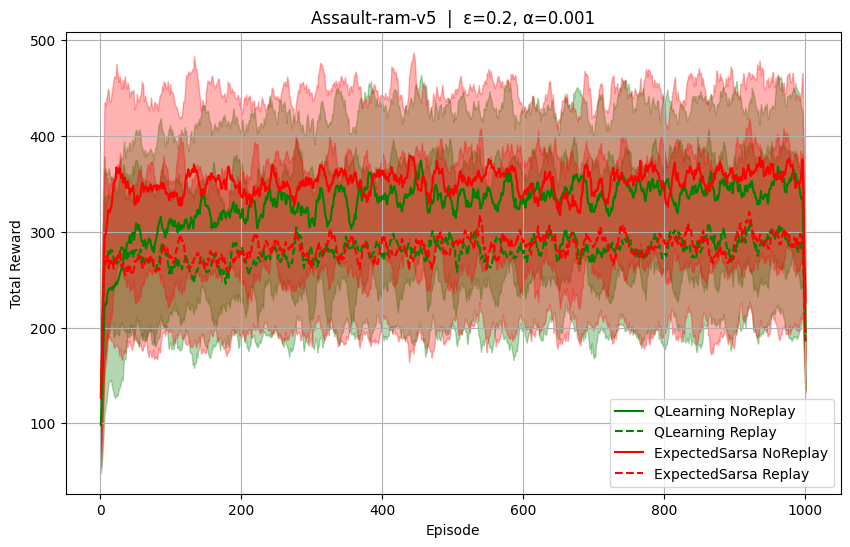

Plotting for Assault-ram-v5: ε=0.2, α=0.01


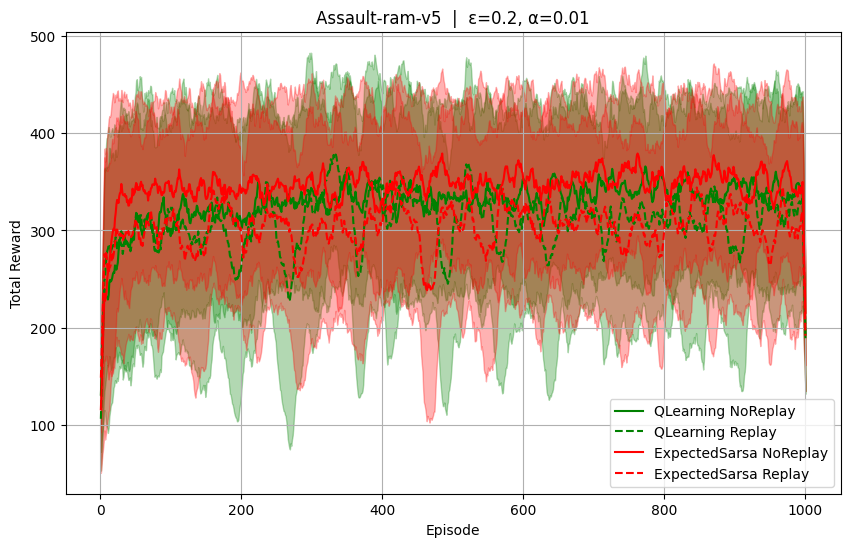

In [9]:
def plot_configurations(env_name, epsilon, alpha, smooth=True, window_size=10):
    """
    For a given configuration (env, epsilon, alpha), this function loads individual trial files
    for the following four cases:
      - QLearning_NoReplay
      - QLearning_Replay
      - ExpectedSarsa_NoReplay
      - ExpectedSarsa_Replay
    It computes the mean and standard deviation across trials (optionally applying smoothing)
    and plots all four curves on a single graph.
    """
    # Construct file patterns for each case.
    base_path = f"/content/drive/MyDrive/COMP_579_A3/results/{env_name}"

    patterns = {
        "QLearning_NoReplay": os.path.join(base_path, f"QLearning_NoReplay", f"QLearning_{env_name}_NoReplay_eps-{epsilon}_alpha-{alpha}_trial-*.npy"),
        "QLearning_Replay": os.path.join(base_path, f"QLearning_Replay", f"QLearning_{env_name}_Replay_eps-{epsilon}_alpha-{alpha}_trial-*.npy"),
        "ExpectedSarsa_NoReplay": os.path.join(base_path, f"ExpectedSarsa_NoReplay", f"ExpectedSarsa_{env_name}_NoReplay_eps-{epsilon}_alpha-{alpha}_trial-*.npy"),
        "ExpectedSarsa_Replay": os.path.join(base_path, f"ExpectedSarsa_Replay", f"ExpectedSarsa_{env_name}_Replay_eps-{epsilon}_alpha-{alpha}_trial-*.npy")
    }

    # A helper to load and aggregate data for a given pattern.
    def load_data(pattern):
        files = glob.glob(pattern)
        if len(files) == 0:
            return None
        trials = [np.load(f) for f in files]
        return np.array(trials)  # shape: (n_trials, n_episodes)

    # Load data for each case.
    data_ql_no = load_data(patterns["QLearning_NoReplay"])
    data_ql_rep = load_data(patterns["QLearning_Replay"])
    data_es_no = load_data(patterns["ExpectedSarsa_NoReplay"])
    data_es_rep = load_data(patterns["ExpectedSarsa_Replay"])

    plt.figure(figsize=(10, 6))

    # Prepare x-axis if any data is available.
    episodes = None
    def process_and_plot(data, color, linestyle, label):
        nonlocal episodes
        if data is None:
            print(f"No data for {label}")
            return
        mean_curve = data.mean(axis=0)
        std_curve = data.std(axis=0)
        if smooth:
            mean_curve = smooth_curve(mean_curve, window_size)
            std_curve = smooth_curve(std_curve, window_size)
        if episodes is None:
            episodes = np.arange(1, len(mean_curve)+1)
        plt.plot(episodes, mean_curve, color=color, linestyle=linestyle, label=label)
        plt.fill_between(episodes, mean_curve - std_curve, mean_curve + std_curve, color=color, alpha=0.3)

    # Plot QLearning curves in green, ExpectedSarsa curves in red.
    process_and_plot(data_ql_no, color="green", linestyle="solid", label="QLearning NoReplay")
    process_and_plot(data_ql_rep, color="green", linestyle="dashed", label="QLearning Replay")
    process_and_plot(data_es_no, color="red", linestyle="solid", label="ExpectedSarsa NoReplay")
    process_and_plot(data_es_rep, color="red", linestyle="dashed", label="ExpectedSarsa Replay")

    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title(f"{env_name}  |  ε={epsilon}, α={alpha}")
    plt.legend()
    plt.grid(True)
    plt.show()

# Loop over all configurations: 2 environments * 3 epsilons * 3 alphas = 18 plots.
envs = ["Acrobot-v1", "Assault-ram-v5"]
epsilons = [0.05, 0.1, 0.2]
alphas = [0.0001, 0.001, 0.01]  # example values

for env in envs:
    for eps in epsilons:
        for alpha in alphas:
            print(f"Plotting for {env}: ε={eps}, α={alpha}")
            plot_configurations(env, eps, alpha, smooth=True, window_size=10)

### Explaination

<u>Acrobot-v1</u>

Across all of the configurations, implementations using a replay buffer consistently outperformed those without. This is most evident in configurations such as ($\epsilon=0.1$ $\alpha=0.0001$), ($\epsilon=0.1$ $\alpha=0.001$), and ($\epsilon=0.2$ $\alpha=0.001$) for the Acrobot-v1 envrionment. The first configuration suffers from significant forgetting, with average rewards dropping to the -500 minimum near episode 100 for QLearning, while Expected SARSA's rewards decay following a peak at episode 400. The other configurations do not learn at all, with results remain at the minimum with erratic peaks only present due to stochaisticity. For Acrobot-v1 configurations with a replay buffer however, long term results (between episode 800-1000) are very similar between QLearning and Expected SARSA.

Two notable results on Acrobot-v1 are the ($\epsilon=0.1$ $\alpha=0.01$) and ($\epsilon=0.2$ $\alpha=0.001$). These show that either a high $\epsilon$ value or a high $\alpha$ (or both) perform poorly due to the excessive stochasticity in action selection due to the policy or due to the large step size inhibiting convergence.

The forgetting or lack of learning exihibited by the non-replay configurations can be explained by correlated experiences, a non-stationary data distribution, and catastrophic forgetting. Consecutive transitions are highly correlated. Without a replay buffer, the agent trains on recent, sequential data rather than on a diversified sample. This correlation can cause unstable learning and make the agent overly sensitive to short-term fluctuations in the environment. Alteritively, as the agent learns, the distribution of observed states changes. Without a replay buffer to reintroduce older experiences, the training data becomes non-stationary. This means that the updates are based on a moving target, making it hard for the agent to converge on reliable value estimates—especially problematic in environments where the dynamics or reward structures can be subtle or sparse. Finally, Without storing and revisiting past experiences, the agent may quickly overwrite older, yet important, transitions with new ones, leading to loss of previously learned behavior.

<u>Assault-ram-v5</u>

Unlike in Acrobot-v1, the QLearning and Expected SARSA implementations in the Assault-ram-v5 environment show a much smaller difference between the with and without replay configurations. This is most noteable in the graphs of ($\epsilon=0.05$ $\alpha=0.0001$), ($\epsilon=0.1$ $\alpha=0.0001$), and ($\epsilon=0.2$ $\alpha=0.0001$), where all of the implementations perform very similarly across all of the episodes. However, the ($\epsilon=0.05$ $\alpha=0.0001$) does show a slightly slower convergence to ultimate performance for the non-replay configuration. Overall, this highlights the importance of $\alpha$ as equal performance can be acheived by tuning this value, evidenced by the afformentioned configurations acheiving the same performance with the same learning rate.

Counterintuatively, better performance is observed in the without replay vs the without replay scenarios for other $\epsilon$ \& $\alpha$ combinations. The biggest differences are seen in ($\epsilon=0.05$ $\alpha=0.001$), ($\epsilon=0.1$ $\alpha=0.001$), and ($\epsilon=0.2$ $\alpha=0.001$) combinations, each showing consistently higher (50-100 rewards difference) performance without a replay buffer. This could indicate that recent transitions are more important in the Assault-ram-v5 environment. When learning only from the most recent experiences, the agent’s updates are directly informed by its current policy and the latest environment dynamics. This can lead to faster adaptation, especially in environments where conditions or strategies change rapidly. Alternatively, in a RAM-based environment like Assault-ram-v5 with its relatively lower-dimensional state representation—older samples might not be as representative of the current state distribution, potentially slowing down learning or even leading the agent astray. Mixing old and new experiences could have diluted important recent signals. By focusing solely on recent, highly relevant transitions, the agents might have avoided interference from experiences that no longer align well with its current strategy, leading to more efficient updates.

All results on 1 plot

Plotting Q-Learning results without replay buffer:


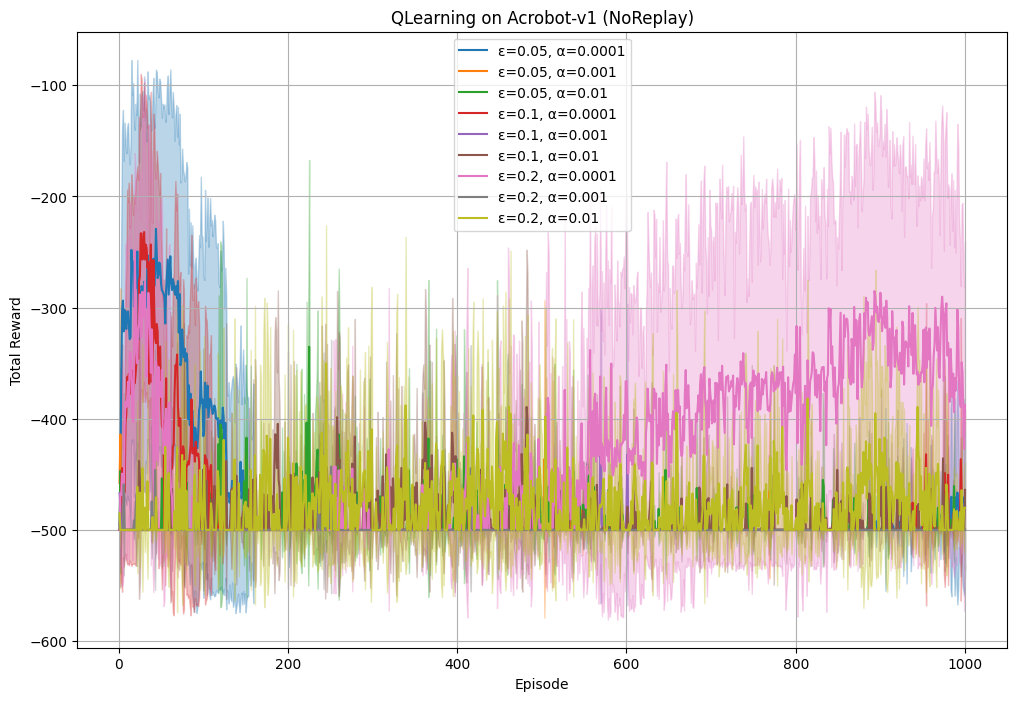

Plotting Q-Learning results with replay buffer:


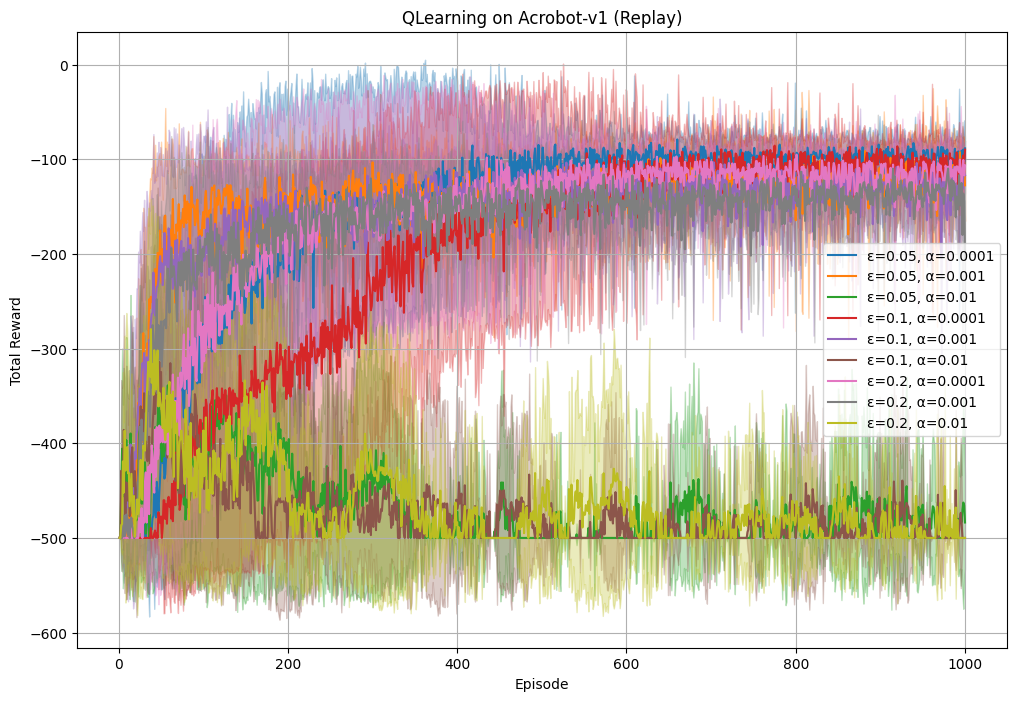

Plotting Expected SARSA results without replay buffer:


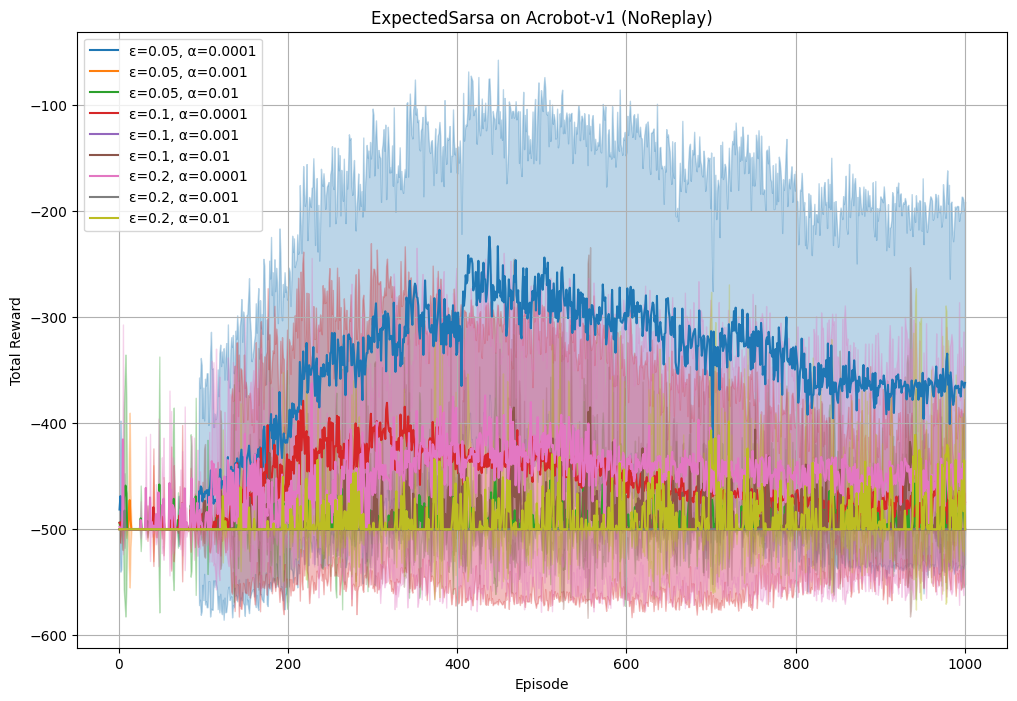

Plotting Expected SARSA results with replay buffer:


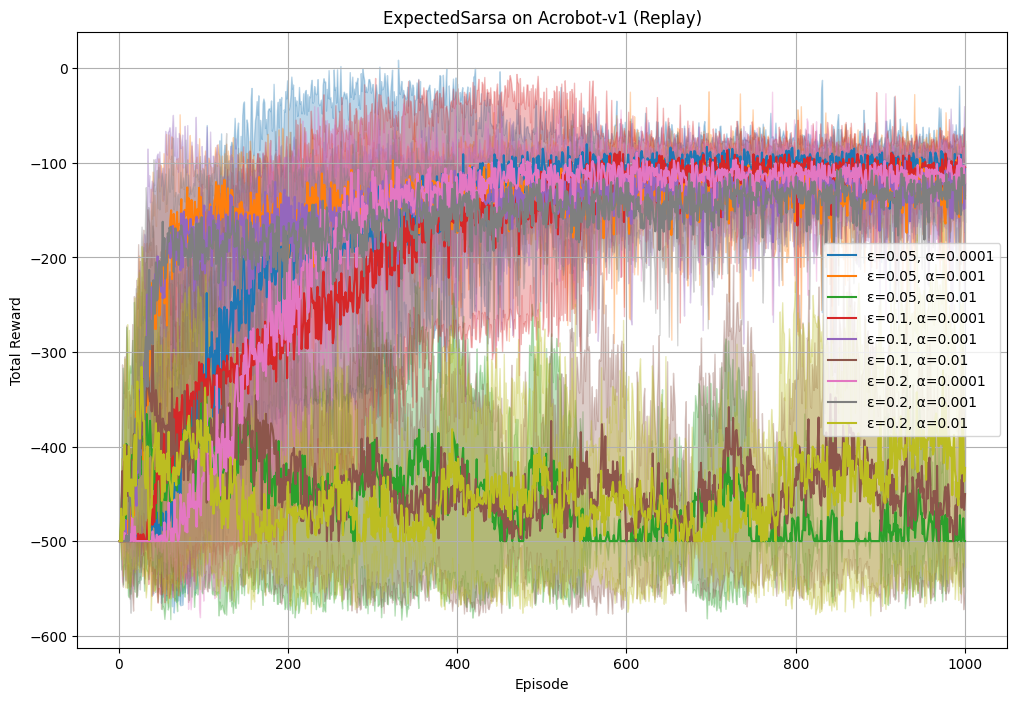

In [10]:
def plot_all_results(env_name, algorithm, buffer_option):
    """
    Scans the results folder for individual trial .npy files,
    groups them by (epsilon, alpha) configuration, computes the mean and std
    across trials, and plots them on a single graph with each configuration
    in a unique color.
    """
    folder = f"/content/drive/MyDrive/COMP_579_A3/results/{env_name}/{algorithm}_{buffer_option}"
    file_pattern = os.path.join(folder, f"{algorithm}_{env_name}_{buffer_option}_eps-*_alpha-*_trial-*.npy")
    files = glob.glob(file_pattern)

    if len(files) == 0:
        print(f"No trial files found in {folder}")
        return

    # Regular expression to extract epsilon and alpha.
    regex = re.compile(rf"{algorithm}_{env_name}_{buffer_option}_eps-([\d.]+)_alpha-([\d.]+)_trial-\d+\.npy")

    # Group files by configuration (epsilon, alpha)
    config_files = defaultdict(list)
    for file in files:
        basename = os.path.basename(file)
        match = regex.search(basename)
        if match:
            eps = float(match.group(1))
            alpha = float(match.group(2))
            config_files[(eps, alpha)].append(file)
        else:
            print(f"File {file} did not match expected pattern.")

    plt.figure(figsize=(12, 8))

    # Use a colormap to assign each configuration a unique color.
    num_configs = len(config_files)
    cmap = plt.get_cmap("tab10")
    # Create a mapping from (eps, alpha) to a distinct color.
    colors = {}
    for idx, key in enumerate(sorted(config_files.keys())):
        colors[key] = cmap(idx / num_configs)

    for (eps, alpha), file_list in sorted(config_files.items()):
        trial_curves = []
        for f in file_list:
            data = np.load(f)
            trial_curves.append(data)
        trial_curves = np.array(trial_curves)  # shape: (num_trials, num_episodes)

        # smoothing
        mean_curve = smooth_curve(trial_curves.mean(axis=0), window_size=10)
        std_curve = smooth_curve(trial_curves.std(axis=0), window_size=10)

        mean_curve = trial_curves.mean(axis=0)
        std_curve = trial_curves.std(axis=0)
        episodes = np.arange(1, mean_curve.shape[0] + 1)
        label = f"ε={eps}, α={alpha}"

        plt.plot(episodes, mean_curve, color=colors[(eps, alpha)], label=label)
        plt.fill_between(episodes, mean_curve - std_curve, mean_curve + std_curve,
                         color=colors[(eps, alpha)], alpha=0.3)

    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title(f"{algorithm} on {env_name} ({buffer_option})")
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage:
env_name = "Acrobot-v1"
# Choose one algorithm and buffer option at a time:
print("Plotting Q-Learning results without replay buffer:")
plot_all_results(env_name, "QLearning", "NoReplay")
print("Plotting Q-Learning results with replay buffer:")
plot_all_results(env_name, "QLearning", "Replay")

print("Plotting Expected SARSA results without replay buffer:")
plot_all_results(env_name, "ExpectedSarsa", "NoReplay")
print("Plotting Expected SARSA results with replay buffer:")
plot_all_results(env_name, "ExpectedSarsa", "Replay")